In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple

import os
from pathlib import Path
import re
import json
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

%config InlineBackend.figure_format='retina'

In [2]:
# Display settings
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# Analyze ProteinGym DMS zero-shot results
This notebook loads pre-computed Spearman correlations from the ProteinGym benchmark, aggregates results, and visualizes distributions with violin plots.

In [3]:
# Define model colors for visualization
colors = {
    "AMPLIFY_350M_hf_mm": "#5AA2FF",
    "AMPLIFY_120M_hf_mm": "#9CC9FF",
    "SaAMPLIFY_350M_hf_mm": "#008C7A",
    "SaAMPLIFY_120M_hf_mm": "#39C7B9",
    "AMPLIFY_120M_UR50": "#7F91AA",
    "AMPLIFY_120Mbase_hf_mm": "#515151",
    "AMPLIFY_350Mbase_hf_mm": "#292929",
    "AMPLIFY_2_350M_consensus_extended": "#004D40",
    "AMPLIFY_2_350M_consensus": "#00332E",
    "AMPLIFY_2_Lolalb_AMPLIFY_benchmark": "#2983D8",
    "ESM2 (8M)": "#F5CFAF",
    "ESM2 (35M)": "#EBAA71",
    "ESM2 (150M)": "#DA8B54",
    "ESM2 (650M)": "#CC7130",
    "ESM2 (3B)": "#AC5B10",
    "ESM2 (15B)": "#7E3F05",
    "SaESM2_650M_hf_mm": "#C49B00",
    "SaESM2_150M_local_mm": "#C49B00",
    "SaESM2_35M_local_mm": "#F4C532",
    "SaESM2_8M_local_mm": "#FFE37D",
    'ESM3 open (1.4B)': "#A87EFF",
    'ESM-C (300M)': "#F04D9B",
    'ESM-C (600M)': "#B01A69",
}

model_sizes = {  # In Millions of parameters
    "AMPLIFY_350M_hf_mm": 350,
    "AMPLIFY_120M_hf_mm": 120,
    "AMPLIFY_120Mbase_hf_mm": 120,
    "AMPLIFY_350Mbase_hf_mm": 350,
    "AMPLIFY_120M_UR50": 120,
    "AMPLIFY_2_350M_consensus_extended": 350,
    "AMPLIFY_2_350M_consensus": 350,
    "AMPLIFY_2_Lolalb_AMPLIFY_benchmark": 350,
    "ESM2 (8M)": 8,
    "ESM2 (35M)": 35,
    "ESM2 (150M)": 150,
    "ESM2 (650M)": 650,
    "ESM2 (3B)": 3000,
    "ESM2 (15B)": 15000,
    "SaESM2_650M_hf_mm": 650,
    "SaESM2_150M_local_mm": 150,
    "SaESM2_35M_local_mm": 35,
    "SaESM2_8M_local_mm": 8,
    "SaAMPLIFY_350M_hf_mm": 350,
    "SaAMPLIFY_120M_hf_mm": 120,
    'ESM3 open (1.4B)': 1400,
    'ESM-C (300M)': 300,
    'ESM-C (600M)': 600,
}
model_families = {
    "AMPLIFY": ["AMPLIFY_350M_hf_mm", "AMPLIFY_120M_hf_mm"],
    "SaAMPLIFY": ["SaAMPLIFY_350M_hf_mm", "SaAMPLIFY_120M_hf_mm"],
    "ESM2": ["ESM2 (8M)", "ESM2 (35M)", "ESM2 (150M)", "ESM2 (650M)", "ESM2 (3B)", "ESM2 (15B)"],
    "SaESM2": ["SaESM2_650M_hf_mm", "SaESM2_150M_local_mm", "SaESM2_35M_local_mm", "SaESM2_8M_local_mm"],
    "ESM-C": ["ESM-C (300M)", "ESM-C (600M)"],
    "ESM3": ["ESM3 open (1.4B)"],
    # "AMPLIFY_C": ["AMPLIFY_2_350M_consensus_extended"],
    # "AMPLIFY_B": ["AMPLIFY_2_Lolalb_AMPLIFY_benchmark"],
}

In [4]:
# Load pre-computed results
results_base_path = Path("/home/mila/d/david.heurtel-depeiges/scratch/proteingym/results/performance/all_models/Spearman")

# Load per-assay (DMS-level) results
dms_level_df = pd.read_csv(results_base_path / "DMS_substitutions_Spearman_DMS_level.csv")
dms_level_df = dms_level_df.set_index("DMS ID")

# Load summary statistics
summary_df = pd.read_csv(results_base_path / "Summary_performance_DMS_substitutions_Spearman.csv")

# Also load the public benchmark for reference
repo_root = Path.cwd().parent
public_benchmark_df = pd.read_csv(
    repo_root / "benchmarks/DMS_zero_shot/substitutions/Spearman/DMS_substitutions_Spearman_DMS_level.csv", 
    index_col=0
)

In [5]:
dms_level_df.head()  # Structure: index is DMS ID, columns are model names

,AMPLIFY,AMPLIFY_120M_hf_mm,AMPLIFY_350M_hf_mm,AMPLIFY_120M_revision_AMPLIFY_120M_2011,AMPLIFY_120M_revision_AMPLIFY_120M_2012,AMPLIFY_120M_revision_AMPLIFY_120M_2013,AMPLIFY_120M_revision_AMPLIFY_120M_2014,AMPLIFY_120M_revision_AMPLIFY_120M_2015,AMPLIFY_120M_revision_AMPLIFY_120M_2016,AMPLIFY_120M_revision_AMPLIFY_120M_2017,AMPLIFY_120M_revision_AMPLIFY_120M_2018,AMPLIFY_120M_revision_AMPLIFY_120M_2019,AMPLIFY_120M_revision_AMPLIFY_120M_2020,AMPLIFY_120M_revision_AMPLIFY_120M_2021,AMPLIFY_120M_revision_AMPLIFY_120M_2022,AMPLIFY_120M_revision_AMPLIFY_120M_2023,AMPLIFY_120Mbase_hf_mm,AMPLIFY_350Mbase_hf_mm,AMPLIFY_120M_UR50,SaESM2_650M_hf_mm,SaESM2_150M_local_mm,SaESM2_35M_local_mm,SaESM2_8M_local_mm,SaAMPLIFY_350M_hf_mm,SaAMPLIFY_120M_hf_mm,AMPLIFY_2_120M_MILA_ALL_0.40,AMPLIFY_2_120M_MILA_ALL_0.50,AMPLIFY_2_120M_MILA_ALL_0.30,AMPLIFY_2_120M_MILA_ALL_0.50_1m,AMPLIFY_2_120M_MILA_ALL_0.60,AMPLIFY_2_120M_MILA_ALL_0.60_1m,AMPLIFY_2_120M_MILA_ALL_0.70,AMPLIFY_2_120M_MILA_ALL_0.70_1m,AMPLIFY_2_120M_MILA_ALL_0.80,AMPLIFY_2_120M_MILA_ALL_0.80_1m,AMPLIFY_2_120M_MILA_ALL_0.90,AMPLIFY_2_120M_MILA_BFD_0.10,AMPLIFY_2_120M_MILA_BFD_0.20,AMPLIFY_2_120M_MILA_BFD_0.20_1m,AMPLIFY_2_120M_MILA_BFD_0.30,AMPLIFY_2_120M_MILA_BFD_0.30_1m,AMPLIFY_2_120M_MILA_BFD_0.40,AMPLIFY_2_120M_MILA_BFD_0.40_1m,AMPLIFY_2_120M_MILA_BFD_0.50,AMPLIFY_2_120M_MILA_BFD_0.50_1m,AMPLIFY_2_120M_MILA_BFD_0.60,AMPLIFY_2_120M_MILA_BFD_0.60_1m,AMPLIFY_2_120M_MILA_BFD_0.70,AMPLIFY_2_120M_MILA_BFD_0.70_1m,AMPLIFY_2_120M_MILA_BFD_0.80,AMPLIFY_2_120M_MILA_BFD_0.80_1m,AMPLIFY_2_120M_MILA_BFD_0.90,AMPLIFY_2_120M_MILA_MGNIFY,AMPLIFY_2_120M_MILA_MGNIFY_0.10,AMPLIFY_2_120M_MILA_MGNIFY_0.20,AMPLIFY_2_120M_MILA_MGNIFY_0.20_1m,AMPLIFY_2_120M_MILA_MGNIFY_0.30,AMPLIFY_2_120M_MILA_MGNIFY_0.30_1m,AMPLIFY_2_120M_MILA_MGNIFY_0.40,AMPLIFY_2_120M_MILA_MGNIFY_0.40_1m,AMPLIFY_2_120M_MILA_MGNIFY_0.50,AMPLIFY_2_120M_MILA_MGNIFY_0.60,AMPLIFY_2_120M_MILA_MGNIFY_0.70,AMPLIFY_2_120M_MILA_MGNIFY_0.80,AMPLIFY_2_120M_MILA_MGNIFY_0.90,AMPLIFY_2_120M_MILA_OPT_0.10_sub10,AMPLIFY_2_120M_MILA_OPT_0.10_sub10_1m,AMPLIFY_2_120M_MILA_OPT_0.20_sub20,AMPLIFY_2_120M_MILA_OPT_0.20_sub20_1m,AMPLIFY_2_120M_MILA_OPT_0.30_sub30_1m,AMPLIFY_2_120M_MILA_OPT_0.40_sub40_1m,AMPLIFY_2_120M_MILA_OPT_0.50_sub50,AMPLIFY_2_120M_MILA_OPT_0.60_sub60,AMPLIFY_2_120M_MILA_U100_0.01,AMPLIFY_2_120M_MILA_U100_0.02,AMPLIFY_2_120M_MILA_U100_0.03,AMPLIFY_2_120M_MILA_U100_0.05,AMPLIFY_2_120M_MILA_U100_0.05_1m,AMPLIFY_2_120M_MILA_U100_0.10,AMPLIFY_2_120M_MILA_U100_0.10_1m,AMPLIFY_2_120M_MILA_U100_0.15,AMPLIFY_2_120M_MILA_U100_0.15_1m,AMPLIFY_2_120M_MILA_U100_0.20,AMPLIFY_2_120M_MILA_U100_0.20_1m,AMPLIFY_2_120M_MILA_U100_0.25,AMPLIFY_2_120M_MILA_U100_0.25_1m,AMPLIFY_2_120M_MILA_U100_0.30,AMPLIFY_2_120M_MILA_U100_0.30_1m,AMPLIFY_2_120M_MILA_U100_0.35,AMPLIFY_2_120M_MILA_U100_0.35_1m,AMPLIFY_2_120M_MILA_U100_0.40,AMPLIFY_2_120M_MILA_U100_0.40_1m,AMPLIFY_2_120M_MILA_U100_0.50,AMPLIFY_2_120M_MILA_U100_0.60,AMPLIFY_2_120M_MILA_U100_0.65,AMPLIFY_2_120M_MILA_U100_0.75,AMPLIFY_2_120M_Lolalb_amplify_opt_0_05_350m,AMPLIFY_2_120M_Lolalb_amplify_opt_0_05_120m_saved,AMPLIFY_2_120M_Lolalb_cluster90_90_opt_0_05_120m,AMPLIFY_2_120M_Lolalb_cluster70_90_opt_0_05_120m,AMPLIFY_2_120M_Lolalb_cluster90_opt_0_05_120m,AMPLIFY_2_120M_Lolalb_cluster_opt_0_05_120m,AMPLIFY_2_350M_consensus_extended,AMPLIFY_2_350M_consensus,AMPLIFY_2_Lolalb_AMPLIFY_benchmark,Number of Mutants,Selection Type,UniProt ID,MSA_Neff_L_category,Taxon
DMS ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A0A140D2T1_ZIKV_Sourisseau_2019,0.404,0.375,0.404,-0.068,-0.047,-0.065,-0.079,0.100,0.231,-0.092,-0.086,0.155,-0.058,-0.061,-0.077,-0.054,-0.101,-0.049,-0.067,0.375,-0.037,-0.067,-0.065,0.410,0.377,-0.032,-0.036,-0.057,-0.032,-0.030,-0.085,-0.085,-0.073,-0.065,-0.049,-0.078,-0.070,0.022,-0.052,0.029,-0.014,-0.006,-0.071,-0.055,-0.068,-0.049,-0.061,0.004,-0.065,-0.055,-0.092,-0.006,-0.040,-0.069,-0.093,-0.051,-0.064,-0.055,-0.048,-0.066,-0.0

In [6]:
# View summary statistics
summary_df.head()

,Model_rank,Model_name,Model type,Average_Spearman,Bootstrap_standard_error_Spearman,Function_Activity,Function_Binding,Function_Expression,Function_OrganismalFitness,Function_Stability,Low_MSA_depth,Medium_MSA_depth,High_MSA_depth,Taxa_Human,Taxa_Other_Eukaryote,Taxa_Prokaryote,Taxa_Virus,Depth_1,Depth_2,Depth_3,Depth_4,Depth_5+,Model details,References
0,1,SaESM2_650M_hf_mm,Single sequence,0.423,0.000,0.428,0.341,0.424,0.375,0.546,0.393,0.428,0.498,0.449,0.505,0.459,0.355,0.429,0.288,0.329,0.282,0.349,NaN,NaN
1,2,SaESM2_150M_local_mm,Single sequence,0.406,0.009,0.416,0.332,0.427,0.329,0.528,0.372,0.388,0.494,0.456,0.489,0.411,0.259,0.410,0.273,0.247,0.252,0.331,NaN,NaN
2,3,AMPLIFY_2_Lolalb_AMPLIFY_benchmark,Single sequence,0.391,0.013,0.397,0.302,0.411,0.349,0.497,0.315,0.385,0.495,0.440,0.464,0.428,0.236,0.389,0.231,0.184,0.166,0.229,NaN,NaN
3,4,AMPLIFY_120M_UR50,Single sequence,0.384,0.013,0.387,0.297,0.418,0.317,0.499,0.280,0.369,0.499,0.436,0.470,0.393,0.212,0.383,0.232,0.158,0.163,0.230,NaN,NaN
4,5,SaAMPLIFY_350M_hf_mm,Single sequence,0.382,0.010,0.389,0.282,0.387,0.359,0.496,0.327,0.405,0.461,0.407,0.466,0.388,0.405,0.384,0.261,0.290,0.270,0.339,NaN,NaN


In [7]:
# Top models by average Spearman
summary_df.nsmallest(20, 'Model_rank')[['Model_rank', 'Model_name', 'Average_Spearman']]

,Model_rank,Model_name,Average_Spearman
0,1,SaESM2_650M_hf_mm,0.423
1,2,SaESM2_150M_local_mm,0.406
2,3,AMPLIFY_2_Lolalb_AMPLIFY_benchmark,0.391
3,4,AMPLIFY_120M_UR50,0.384
4,5,SaAMPLIFY_350M_hf_mm,0.382
5,6,AMPLIFY_2_350M_consensus_extended,0.382
6,7,SaAMPLIFY_120M_hf_mm,0.382
7,8,AMPLIFY_2_350M_consensus,0.371
8,9,AMPLIFY_2_120M_Lolalb_cluster_opt_0_05_120m,0.369
9,10,AMPLIFY_2_120M_Lolalb_cluster70_90_opt_0_05_120m,0.365


In [8]:
public_benchmark_df.head()

,Site-Independent,EVmutation,DeepSequence (single),DeepSequence (ensemble),EVE (single),EVE (ensemble),Unirep,Unirep evotuned,MSA Transformer (single),MSA Transformer (ensemble),ESM-1b,ESM-1v (single),ESM-1v (ensemble),ESM2 (8M),ESM2 (35M),ESM2 (150M),ESM2 (650M),ESM2 (3B),ESM2 (15B),Wavenet,RITA S,RITA M,RITA L,RITA XL,Progen2 S,Progen2 M,Progen2 Base,Progen2 L,Progen2 XL,GEMME,VESPA,VESPAl,VespaG,ProtGPT2,Tranception S no retrieval,Tranception M no retrieval,Tranception L no retrieval,Tranception S,Tranception M,Tranception L,TranceptEVE S,TranceptEVE M,TranceptEVE L,CARP (38M),CARP (600K),CARP (640M),CARP (76M),MIF,MIF-ST,ESM-IF1,ProteinMPNN,"ProtSSN (k=10, h=512)","ProtSSN (k=10, h=768)","ProtSSN (k=10, h=1280)","ProtSSN (k=20, h=512)","ProtSSN (k=20, h=768)","ProtSSN (k=20, h=1280)","ProtSSN (k=30, h=512)","ProtSSN (k=30, h=768)","ProtSSN (k=30, h=1280)",ProtSSN (ensemble),SaProt (650M),SaProt (35M),PoET (200M),MULAN,ProSST (K=20),ProSST (K=128),ProSST (K=512),ProSST (K=1024),ProSST (K=2048),ProSST (K=4096),ESCOTT,VenusREM,RSALOR,S2F,S2F-MSA,S3F,S3F-MSA,SiteRM,ESM3 open (1.4B),ESM-C (300M),ESM-C (600M),xTrimoPGLM-1B-MLM,xTrimoPGLM-3B-MLM,xTrimoPGLM-10B-MLM,xTrimoPGLM-1B-CLM,xTrimoPGLM-3B-CLM,xTrimoPGLM-7B-CLM,xTrimoPGLM-100B-int4,Progen3 112m,Progen3 219m,Progen3 339m,Progen3 762m,Progen3 1B,Progen3 3B,AIDO Protein-RAG (16B),Protriever,Number of Mutants,Selection Type,UniProt ID,MSA_Neff_L_category,Taxon
DMS ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A0A140D2T1_ZIKV_Sourisseau_2019,0.383,0.354,0.131,0.103,0.394,0.405,-0.133,0.062,0.436,0.439,-0.001,-0.048,0.015,-0.073,-0.054,-0.058,0.213,0.363,0.375,0.216,0.361,0.309,0.317,0.305,0.329,0.342,0.328,0.312,0.293,0.430,0.319,0.296,0.380,0.005,0.304,0.331,0.272,0.362,0.366,0.351,0.361,0.358,0.373,-0.060,-0.073,0.131,-0.061,0.273,0.290,0.287,0.129,0.253,0.251,0.282,0.296,0.277,0.269,0.263,0.269,0.265,0.278,0.199,0.116,0.429,0.071,0.107,0.102,0.113,0.113,0.280,0.112,0.471,0.387,0.423,0.285,0.402,0.308,0.418,0.415,0.277,-0.058,-0.048,-0.048,0.366,0.373,0.332,0.282,-0.024,0.303,0.032,0.191,0.305,0.298,0.354,0.338,0.427,0.477,9576,OrganismalFitness,A0A140D2T1_ZIKV,Medium,Virus
A0A192B1T2_9HIV1_Haddox_2018,0.481,0.407,0.413,0.432,0.509,0.516,0.000,0.513,0.511,0.515,0.456,0.492,0.516,-0.003,0.015,0.035,0.080,0.132,0.164,0.465,0.496,0.507,0.509,0.505,0.497,0.501,0.463,0.490,0.484,0.496,0.541,0.507,0.299,0.327,0.492,0.483,0.514,0.509,0.503,0.513,0.524,0.518,0.528,0.422,-0.021,0.497,0.429,0.329,0.451,0.206,0.136,0.202,0.230,0.258,0.263,0.210,0.226,0.228,0.200,0.183,0.239,0.173,0.084,0.488,0.051,0.341,0.383,0.382,0.404,0.447,0.419,0.522,0.562,0.532,0.307,0.523,0.365,0.552,0.515,0.257,0.478,0.460,0.488,0.521,0.466,0.476,0.332,0.024,0.334,0.409,0.482,0.471,0.473,0.487,0.499,0.595,0.504,12577,OrganismalFitness,A0A192B1T2_9HIV1,Medium,Virus
A0A1I9GEU1_NEIME_Kennouche_2019,-0.011,0.044,0.107,0.098,0.053,0.054,-0.024,0.084,0.082,0.077,0.040,0.068,0.068,-0.037,-0.047,-0.016,0.030,0.027,0.025,0.067,-0.010,0.047,0.071,0.088,0.050,0.088,0.080,0.089,0.095,0.045,0.046,0.036,0.033,0.030,0.036,0.055,0.099,0.031,0.041,0.057,0.058,0.061,0.075,-0.055,-0.056,0.039,-0.043,0.051,0.055,0.039,0.040,0.054,0.042,0.039,0.035,0.037,0.052,0.039,0.058,0.041,0.047,0.040,-0.005,0.057,-0.016,0.146,0.177,0.199,0.176,0.076,0.182,0.041,0.070,-0.010,0.043,0.055,0.049,0.058,0.061,0.025,0.058,0.051,0.042,0.051,0.053,0.061,0.020,0.037,0.065,-0.019,0.008,0.043,0.059,0.088,0.094,0.064,0.056,922,Activity,A0A1I9GEU1_NEIME,Medium,Prokaryote
A0A247D711_LISMN_Stadelmann_2021,0.436,0.459,0.109,0.041,0.428,0.428,0.003,0.026,0.299,0.320,0.087,0.088,0.093,0.064,0.084,0.097,0.066,0.084,0.084,0.059,0.021,0.015,0.040,0.078,-0.029,0.067,0.010,0.037,0.106,0.473,0.337,0.351,0.382,0.093,0.041,0.024,0.057,0.301,0.292,0.311,0.253,0.242,0.263,0.047,0.002,0.074,0.084,0.418,0.441,0.476,0.364,0.274,0.326,0.314,0.344,0.313,0.360,0.312,0.331,0.265,0.335,0.427,0.280,0.458,0.162,0.450,0.476,0

In [9]:
# For every public model, try to extract a model size. If you can regexpr a number followed by M or m, assume it's in millions of parameters. If B or b, assume billions.
model_size_extracted = {}
new_families = {}
for model_name in public_benchmark_df.columns:
    match = re.search(r'(\d+)([MmBb])', model_name)
    if match:
        size = int(match.group(1))
        unit = match.group(2).lower()
        if unit == 'm':
            model_size_extracted[model_name] = size
        elif unit == 'b':
            model_size_extracted[model_name] = size * 1000
    elif model_name in ['Number of Mutants', 'Selection Type', 'UniProt ID', 'MSA_Neff_L_category', 'Taxon']:
        continue  # Not a model
    elif model_name.startswith('RITA'):
        # RITA models: RITA-S (77M), RITA-M (307M), RITA-L (1.2B)
        if 'RITA S' in model_name:
            model_size_extracted[model_name] = 85
        elif 'RITA M' in model_name:
            model_size_extracted[model_name] = 300
        elif 'RITA L' in model_name:
            model_size_extracted[model_name] = 680
        elif 'RITA XL' in model_name:
            model_size_extracted[model_name] = 1200
        if new_families.get('RITA', None) is None:
            new_families['RITA'] = []
        new_families['RITA'].append(model_name)
    elif model_name.startswith('Progen2'):
        # Progen2 models: Progen2-S (151M), Progen2-M (408M), Progen2-L (1.2B)
        if 'Progen2 S' in model_name:
            model_size_extracted[model_name] = 151
        elif 'Progen2 M' in model_name:
            model_size_extracted[model_name] = 764
        # elif 'Progen2 Base' in model_name:
        #     model_size_extracted[model_name] = 764
        elif 'Progen2 L' in model_name:
            model_size_extracted[model_name] = 2700
        elif 'Progen2 XL' in model_name:
            model_size_extracted[model_name] = 6400
        if new_families.get('Progen2', None) is None:
            new_families['Progen2'] = []
        new_families['Progen2'].append(model_name)
    elif model_name.startswith('ESM-1v'):
        if 'ESM-1v (single)' in model_name:
            model_size_extracted[model_name] = 650
        elif 'ESM-1v (ensemble)' in model_name:
            model_size_extracted[model_name] = 650 * 5  # Ensemble of 5 models
        if new_families.get('ESM-1v', None) is None:
            new_families['ESM-1v'] = []
        new_families['ESM-1v'].append(model_name)
    elif model_name.startswith('Tranception'):
        if 'Tranception S' in model_name:
            model_size_extracted[model_name] = 85
        elif 'Tranception M' in model_name:
            model_size_extracted[model_name] = 300
        elif 'Tranception L' in model_name:
            model_size_extracted[model_name] = 700
        if 'retrieval' in model_name:
            if new_families.get('Tranception with retrieval', None) is None:
                new_families['Tranception with retrieval'] = []
            new_families['Tranception with retrieval'].append(model_name)
        else:
            if new_families.get('Tranception', None) is None:
                new_families['Tranception'] = []
            new_families['Tranception'].append(model_name)
    elif 'ProSST' in model_name:
        model_size_extracted[model_name] = 110
    elif 'ProtSSN' in model_name:
        if 'ensemble' not in model_name:
            # extract the value of the k=N, h=M parameters
            k_match = re.search(r'k=(\d+)', model_name)
            h_match = re.search(r'h=(\d+)', model_name)
            if h_match:
                h_int = int(h_match.group(1))
                if h_int==512:
                    model_size = 148
                elif h_int==768:
                    model_size = 160
                elif h_int==1280:
                    model_size = 184
            model_size_extracted[model_name] = model_size
        else:
            model_size_extracted[model_name] = 3 * (148 + 160 + 184)  # Ensemble of 9 models
    elif 'MSA Transformer' in model_name:
        if 'single' in model_name:
            model_size_extracted[model_name] = 100
        elif 'ensemble' in model_name:
            model_size_extracted[model_name] = 100 * 5  # Ensemble of 5 models
    else:
        model_size_extracted[model_name] = None  # Size not found

In [10]:
model_size_extracted

{'Site-Independent': None,
 'EVmutation': None,
 'DeepSequence (single)': None,
 'DeepSequence (ensemble)': None,
 'EVE (single)': None,
 'EVE (ensemble)': None,
 'Unirep': None,
 'Unirep evotuned': None,
 'MSA Transformer (single)': 100,
 'MSA Transformer (ensemble)': 500,
 'ESM-1b': 1000,
 'ESM-1v (single)': 650,
 'ESM-1v (ensemble)': 3250,
 'ESM2 (8M)': 8,
 'ESM2 (35M)': 35,
 'ESM2 (150M)': 150,
 'ESM2 (650M)': 650,
 'ESM2 (3B)': 3000,
 'ESM2 (15B)': 15000,
 'Wavenet': None,
 'RITA S': 85,
 'RITA M': 300,
 'RITA L': 680,
 'RITA XL': 1200,
 'Progen2 S': 151,
 'Progen2 M': 764,
 'Progen2 L': 2700,
 'Progen2 XL': 6400,
 'GEMME': None,
 'VESPA': None,
 'VESPAl': None,
 'VespaG': None,
 'ProtGPT2': None,
 'Tranception S no retrieval': 85,
 'Tranception M no retrieval': 300,
 'Tranception L no retrieval': 700,
 'Tranception S': 85,
 'Tranception M': 300,
 'Tranception L': 700,
 'TranceptEVE S': None,
 'TranceptEVE M': None,
 'TranceptEVE L': None,
 'CARP (38M)': 38,
 'CARP (600K)': None,


In [11]:
# Prepare data for visualization
# Convert wide format to long format for plotting

# First, merge dms_level_df with public_benchmark_df to include all models
# The public benchmark has metadata columns that we need to exclude
metadata_cols = ['Number of Mutants', 'Selection Type', 'UniProt ID', 'MSA_Neff_L_category', 'Taxon']
public_scores = public_benchmark_df.drop(columns=[col for col in metadata_cols if col in public_benchmark_df.columns], errors='ignore')

# Combine both dataframes (new results + public benchmark)
# For overlapping models, prefer dms_level_df (new results)
all_models_df = dms_level_df.copy()
for col in public_scores.columns:
    if col not in all_models_df.columns:
        all_models_df[col] = public_scores[col]

# Convert to long format
long_rows = []
for assay in all_models_df.index:
    for model in all_models_df.columns:
        score = all_models_df.loc[assay, model]
        if pd.notna(score):
            long_rows.append({
                'model': model,
                'assay': assay,
                'spearman': score
            })

long_df = pd.DataFrame(long_rows)
print(f"Total assays: {long_df['assay'].nunique()}, Total models: {long_df['model'].nunique()}")
long_df.head()

Total assays: 217, Total models: 207


,model,assay,spearman
0,AMPLIFY,A0A140D2T1_ZIKV_Sourisseau_2019,0.404
1,AMPLIFY_120M_hf_mm,A0A140D2T1_ZIKV_Sourisseau_2019,0.375
2,AMPLIFY_350M_hf_mm,A0A140D2T1_ZIKV_Sourisseau_2019,0.404
3,AMPLIFY_120M_revision_AMPLIFY_120M_2011,A0A140D2T1_ZIKV_Sourisseau_2019,-0.068
4,AMPLIFY_120M_revision_AMPLIFY_120M_2012,A0A140D2T1_ZIKV_Sourisseau_2019,-0.047


In [12]:
# Select models to visualize
# Filter to models of interest
models_to_plot = [
    'AMPLIFY_120M_hf_mm', 'AMPLIFY_350M_hf_mm',
    'SaAMPLIFY_120M_hf_mm', 'SaAMPLIFY_350M_hf_mm',
    'SaESM2_650M_hf_mm', 'SaESM2_150M_local_mm', 'SaESM2_35M_local_mm', 'SaESM2_8M_local_mm',
    'ESM2 (8M)', 'ESM2 (35M)', 'ESM2 (150M)', 'ESM2 (650M)', 'ESM2 (3B)', 'ESM2 (15B)',
    'AMPLIFY_2_350M_consensus_extended', 'AMPLIFY_2_Lolalb_AMPLIFY_benchmark'
]

# Filter long_df to only include these models
long_df_filtered = long_df[long_df['model'].isin(models_to_plot)].copy()
long_df_filtered.head()

,model,assay,spearman
1,AMPLIFY_120M_hf_mm,A0A140D2T1_ZIKV_Sourisseau_2019,0.375
2,AMPLIFY_350M_hf_mm,A0A140D2T1_ZIKV_Sourisseau_2019,0.404
19,SaESM2_650M_hf_mm,A0A140D2T1_ZIKV_Sourisseau_2019,0.375
20,SaESM2_150M_local_mm,A0A140D2T1_ZIKV_Sourisseau_2019,-0.037
21,SaESM2_35M_local_mm,A0A140D2T1_ZIKV_Sourisseau_2019,-0.067


In [13]:
# Display aggregated scores from summary_df
if 'summary_df' in globals() and not summary_df.empty:
    print("\nProteinGym Official Macro-Averaged Scores:")
    # Show top 20 models by average Spearman
    display(summary_df.nsmallest(20, 'Model_rank')[['Model_rank', 'Model_name', 'Average_Spearman', 'Bootstrap_standard_error_Spearman']])


ProteinGym Official Macro-Averaged Scores:


,Model_rank,Model_name,Average_Spearman,Bootstrap_standard_error_Spearman
0,1,SaESM2_650M_hf_mm,0.423,0.000
1,2,SaESM2_150M_local_mm,0.406,0.009
2,3,AMPLIFY_2_Lolalb_AMPLIFY_benchmark,0.391,0.013
3,4,AMPLIFY_120M_UR50,0.384,0.013
4,5,SaAMPLIFY_350M_hf_mm,0.382,0.010
5,6,AMPLIFY_2_350M_consensus_extended,0.382,0.014
6,7,SaAMPLIFY_120M_hf_mm,0.382,0.009
7,8,AMPLIFY_2_350M_consensus,0.371,0.015
8,9,AMPLIFY_2_120M_Lolalb_cluster_opt_0_05_120m,0.369,0.014
9,10,AMPLIFY_2_120M_Lolalb_cluster70_90_opt_0_05_120m,0.365,0.013


In [14]:
# Add public benchmark models to summary_df
# Load the pre-aggregated summary scores from the public benchmark
public_summary_path = repo_root / "benchmarks" / "DMS_zero_shot" / "substitutions" / "Spearman" / "Summary_performance_DMS_substitutions_Spearman.csv"
public_summary_df = pd.read_csv(public_summary_path)

# Find models that are in public benchmark but not in our summary_df
models_in_summary = set(summary_df['Model_name'].values)
models_in_public = set(public_summary_df['Model_name'].values)
missing_models = models_in_public - models_in_summary

if missing_models:
    print(f"Adding {len(missing_models)} models from public benchmark to summary_df")
    # Filter public_summary_df for missing models and concatenate
    missing_df = public_summary_df[public_summary_df['Model_name'].isin(missing_models)]
    summary_df = pd.concat([summary_df, missing_df], ignore_index=True)
    # Re-rank all models
    summary_df = summary_df.sort_values('Average_Spearman', ascending=False).reset_index(drop=True)
    summary_df['Model_rank'] = range(1, len(summary_df) + 1)
    print(f"Updated summary_df now has {len(summary_df)} models")
else:
    print("All public benchmark models already in summary_df")

Adding 97 models from public benchmark to summary_df
Updated summary_df now has 202 models


In [15]:
def sanitize_model_name(name):
    txt = name
    # Match size anywhere in the string, not just at the end
    match = re.match(r"^(.*)_(\d+M)(?:_.*)?$", txt)
    if match:
        model_part = match.group(1)
        size_part = match.group(2)
        return f"{model_part} ({size_part})"
    return name

/tmp/ipykernel_565286/2801682974.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=long_df_ordered, y='spearman', x='model', inner='box', cut=0, palette=colors)
/tmp/ipykernel_565286/2801682974.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sanitized_labels)


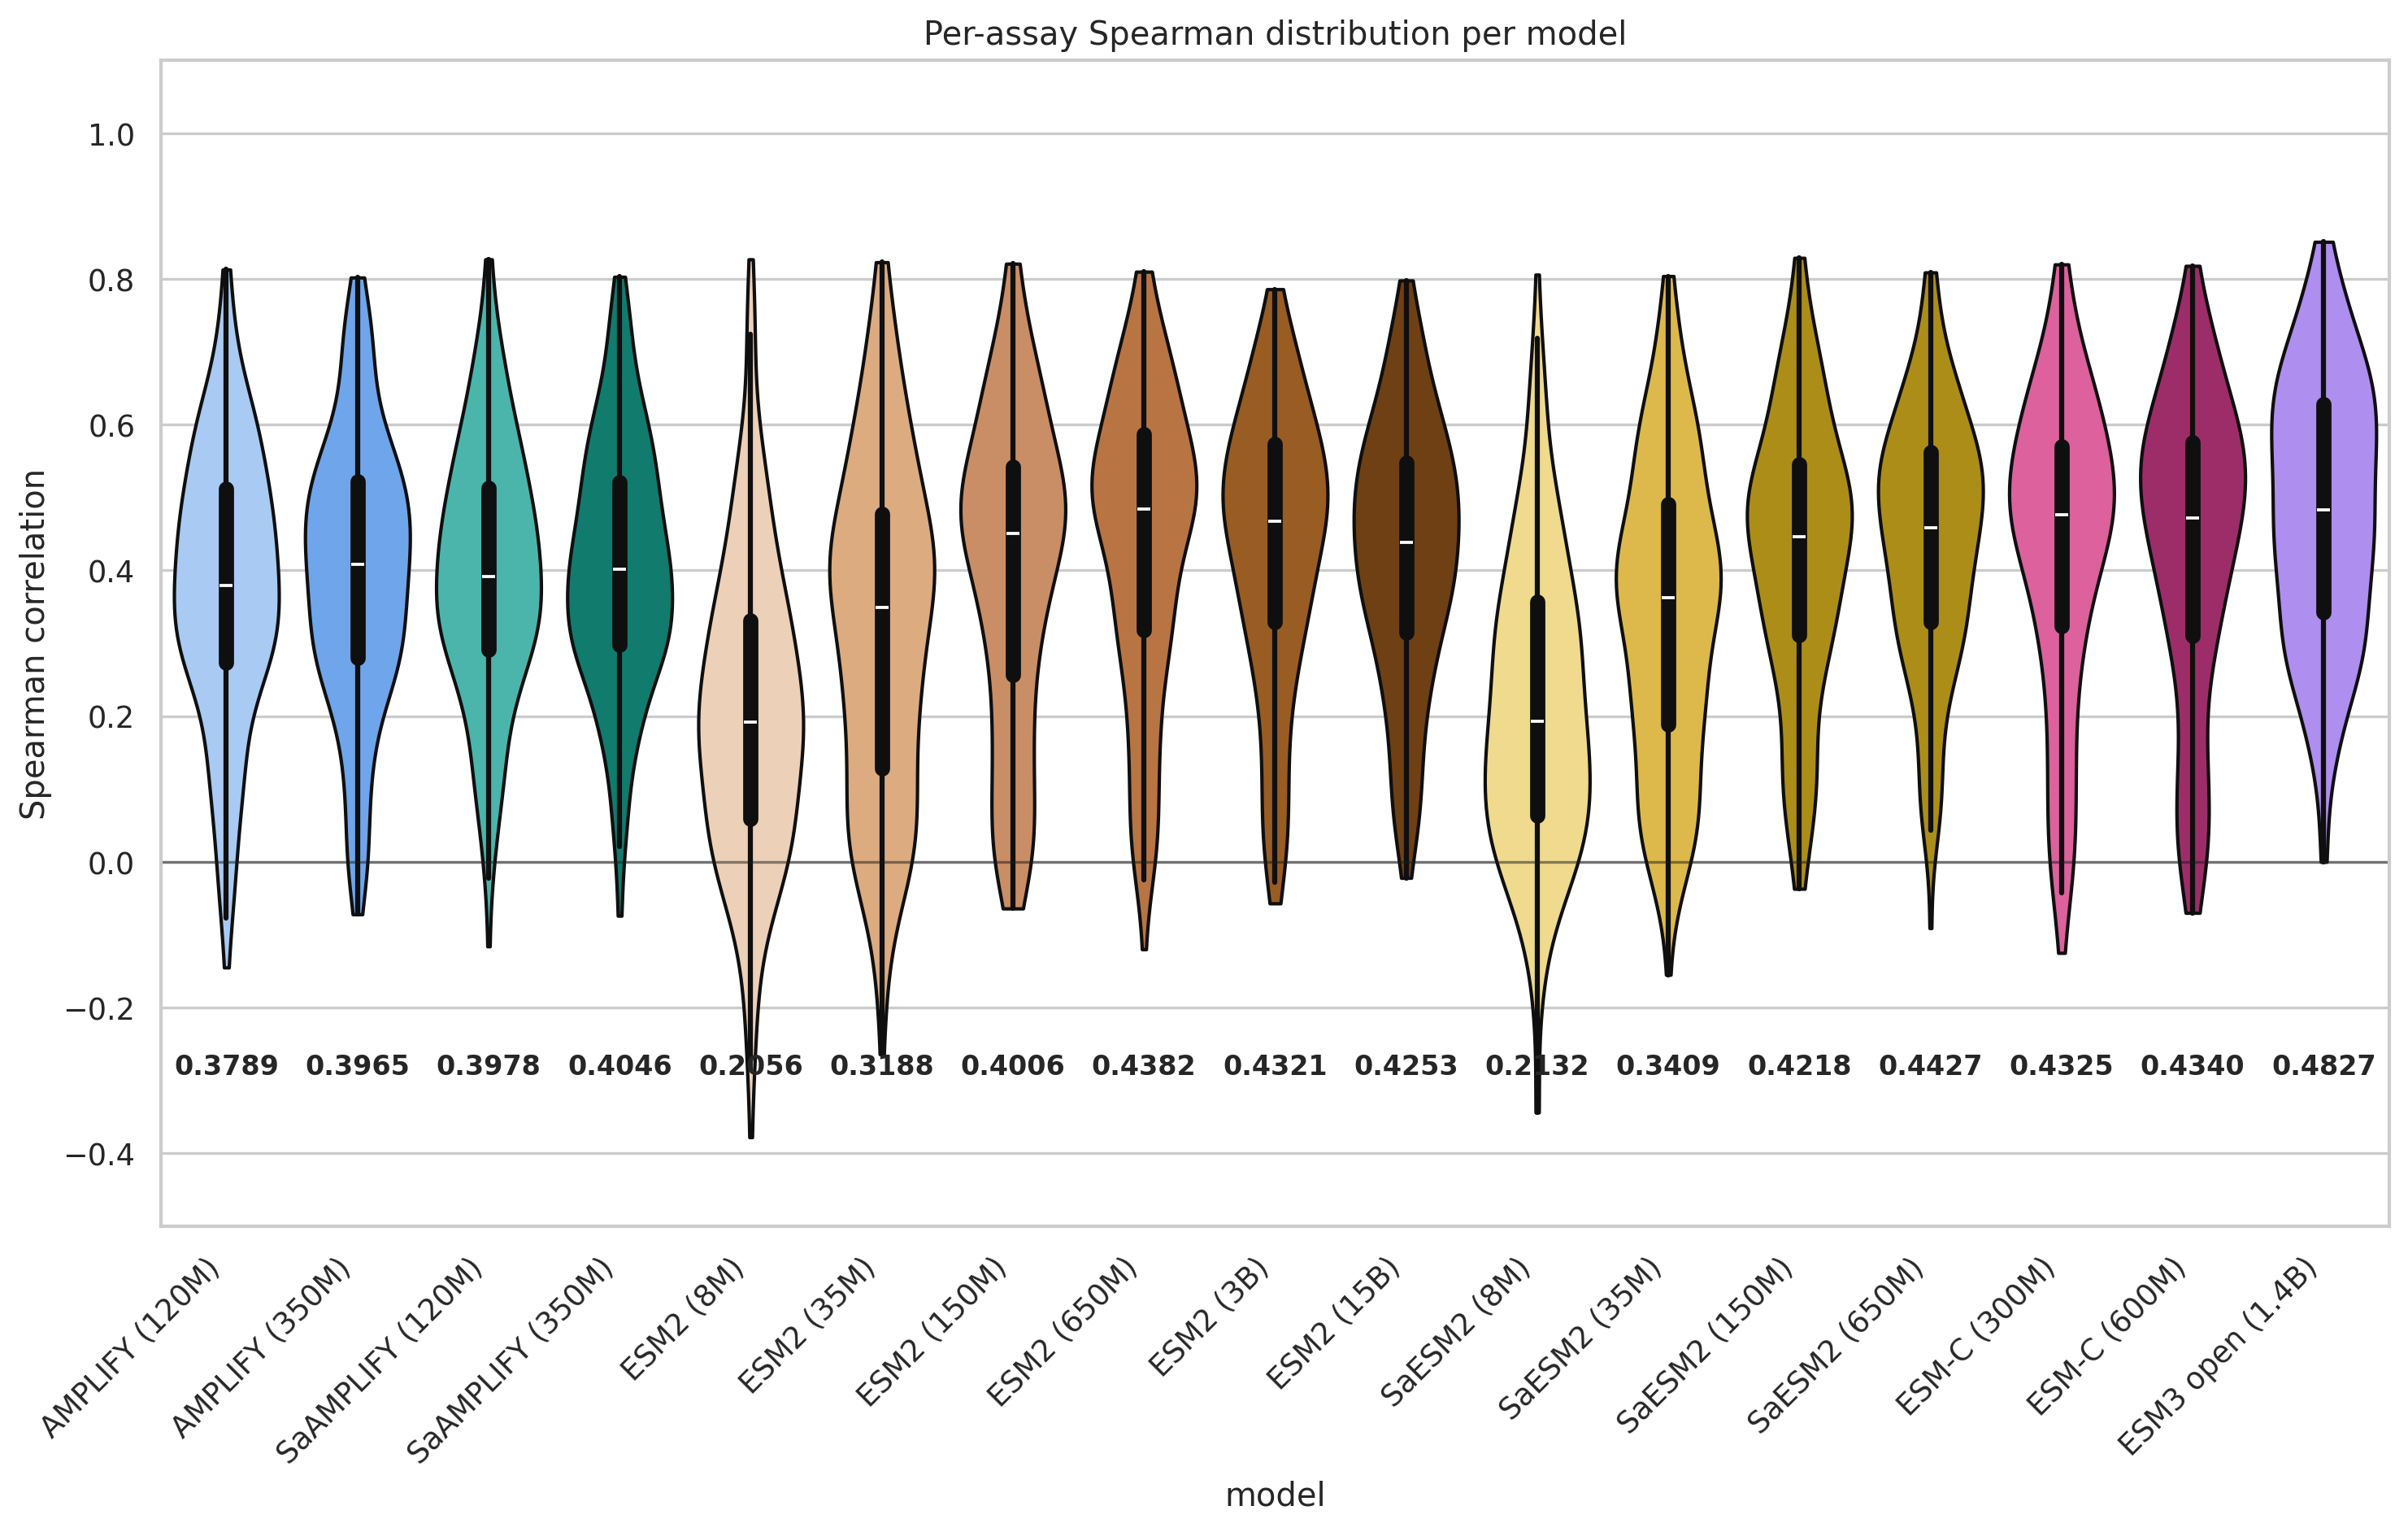

In [16]:
# Violin plot comparing models
if 'long_df' in globals() and not long_df.empty:
    # Create custom ordering by family and model size
    ordered_models = []
    for family, models in model_families.items():
        # Filter models that exist in the data and have size info
        family_models = [m for m in models if m in long_df['model'].unique() and m in model_sizes]
        # Sort by model size within family
        family_models.sort(key=lambda x: model_sizes[x])
        ordered_models.extend(family_models)
    
    # Reorder the dataframe
    long_df_ordered = long_df[long_df['model'].isin(ordered_models)].copy()
    long_df_ordered['model'] = pd.Categorical(long_df_ordered['model'], categories=ordered_models, ordered=True)
    
    plt.figure(figsize=(4 + 0.5*len(ordered_models), 8))
    ax = sns.violinplot(data=long_df_ordered, y='spearman', x='model', inner='box', cut=0, palette=colors)
    ax.axhline(0.0, color='k', lw=1, ls='-', alpha=0.5)
    ax.set_ylim(-0.5, 1.1)
    
    # Sanitize x-axis labels
    sanitized_labels = [sanitize_model_name(m) for m in ordered_models]
    ax.set_xticklabels(sanitized_labels)
    
    # Add mean values as text on the plot
    for i, model in enumerate(ordered_models):
        model_data = long_df_ordered[long_df_ordered['model'] == model]['spearman']
        if not model_data.empty:
            mean_val = model_data.mean()
            ax.text(i, -0.3, f'{mean_val:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_title('Per-assay Spearman distribution per model')
    ax.set_ylabel('Spearman correlation')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")

/tmp/ipykernel_565286/1419034444.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_ = sns.violinplot(
/tmp/ipykernel_565286/1419034444.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sanitized_names)
/tmp/ipykernel_565286/1419034444.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_ = sns.violinplot(
/tmp/ipykernel_565286/1419034444.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sanitized_names)
/tmp/ipykernel_565286/1419034444.py:43: FutureWarning: 

Passing `palette` without assigning `

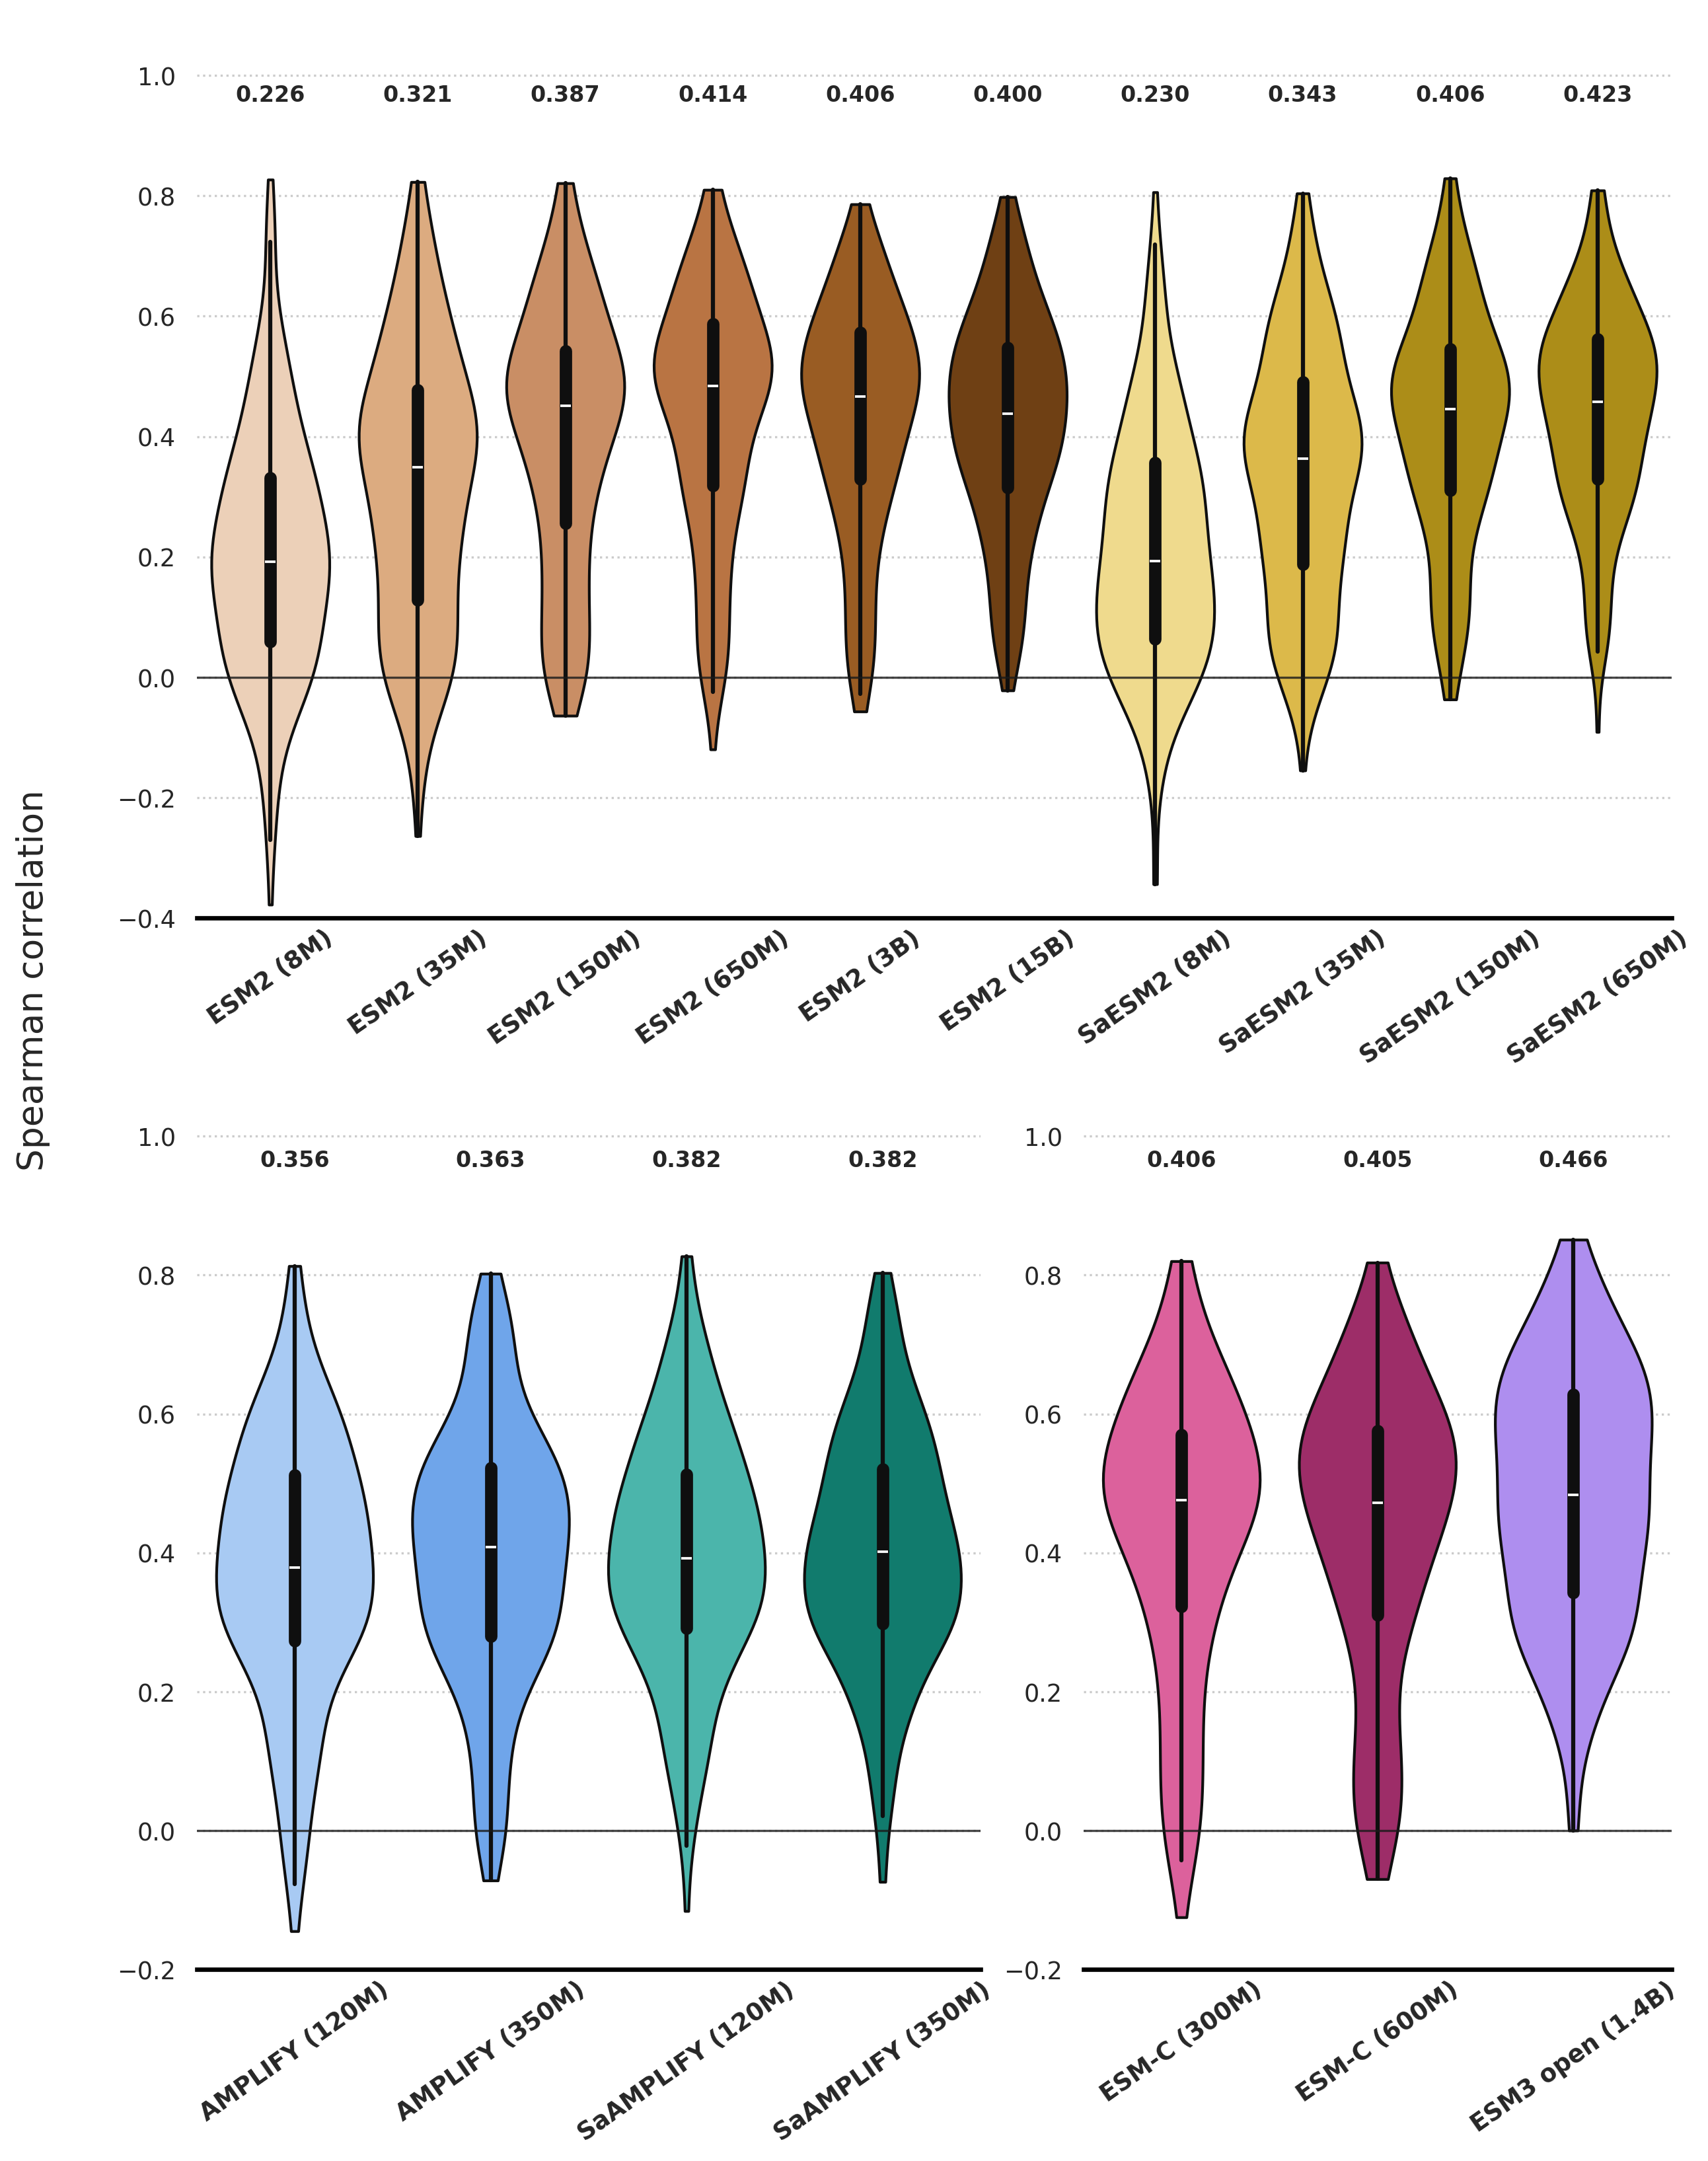

In [17]:
# Split violin plots by families: top (ESM + SaESM), bottom-left (AMPLIFY + SaAMPLIFY), bottom-right (ESM-C + ESM3)
if 'long_df' in globals() and not long_df.empty:
    def ordered_models_for_families(families):
        ordered = []
        for fam in families:
            fam_models = [m for m in model_families.get(fam, [])
                          if m in long_df['model'].unique() and m in model_sizes]
            fam_models.sort(key=lambda x: model_sizes[x])
            ordered.extend(fam_models)
        return ordered

    fam_top = ['ESM2', 'SaESM2']
    fam_bl = ['AMPLIFY', 'SaAMPLIFY']
    fam_br = ['ESM-C', 'ESM3']

    ordered_top = ordered_models_for_families(fam_top)
    ordered_bl = ordered_models_for_families(fam_bl)
    ordered_br = ordered_models_for_families(fam_br)

    top_df = long_df[long_df['model'].isin(ordered_top)].copy()
    bl_df = long_df[long_df['model'].isin(ordered_bl)].copy()
    br_df = long_df[long_df['model'].isin(ordered_br)].copy()

    top_df['model'] = pd.Categorical(top_df['model'], categories=ordered_top, ordered=True)
    bl_df['model'] = pd.Categorical(bl_df['model'], categories=ordered_bl, ordered=True)
    br_df['model'] = pd.Categorical(br_df['model'], categories=ordered_br, ordered=True)

    # Figure layout: top spans both columns; bottom has unequal widths (4 vs 3 models)
    fig = plt.figure(figsize=(max(12, 0.8*len(ordered_top)), 16))
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 3], height_ratios=[2, 2], hspace=0.165, wspace=0.15)

    ax_top = fig.add_subplot(gs[0, :])
    ax_bl = fig.add_subplot(gs[1, 0])
    ax_br = fig.add_subplot(gs[1, 1])

    # Common plotting helper
    def draw_violin(ax, data, ordered_models, title, min_ylim=-0.4):
        if data.empty or not ordered_models:
            ax.set_visible(False)
            return
        # Use sanitized model names for x-axis labels
        sanitized_names = [sanitize_model_name(m) for m in ordered_models]
        ax_ = sns.violinplot(
            data=data, y='spearman', x='model', inner='box', cut=0,
            palette=colors, ax=ax
        )
        ax.set_xticklabels(sanitized_names)
        ax.axhline(0.0, color='k', lw=1, ls='-', alpha=0.8)
        ax.set_ylim(min_ylim, 1.1)
        # ax.set_title(title)
        ax.set_xlabel("", fontdict={'fontsize': 1})
        ax.set_ylabel('', fontdict={'fontsize': 1})
        # Blog guidelines styling
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.spines["bottom"].set_linewidth(2)
        ax.spines["bottom"].set_color("#000000")
        ax.yaxis.grid(True, which="major", linestyle=":")
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', length=0)
        import matplotlib.transforms as mtransforms
        xt = np.array(ax.get_xticks(), dtype=float)
        spacing = float(np.median(np.diff(xt))) if xt.size > 1 else 1.0
        for lbl in ax.get_xticklabels():
            # If the label is modelname_size, transform that to modelname (sizeM)
            lbl.set_rotation(35)
            lbl.set_fontweight('bold')
                # lbl.set_ha('right')
            # lbl.set_ha('right')
            # lbl.set_transform(lbl.get_transform() + mtransforms.ScaledTranslation(spacing/3.0, 0, ax.transData))
        
        # Add per-model mean on top of each violin (using Summary file aggregation)
        for i, model in enumerate(ordered_models):
            # Use summary_df if available, otherwise compute from data
            if 'summary_df' in globals():
                model_row = summary_df[summary_df['Model_name'] == model]
                if not model_row.empty:
                    mean_val = model_row['Average_Spearman'].values[0]
                else:
                    # Fallback to computing mean from data
                    model_data = data[data['model'] == model]['spearman']
                    mean_val = model_data.mean() if not model_data.empty else 0.0
            
            # Position text at top of plot (y=0.95 for consistent alignment)
            ax.text(i, 0.95, f'{mean_val:.3f}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))


    draw_violin(ax_top, top_df, ordered_top, 'ESM / SaESM', -0.4)
    draw_violin(ax_bl, bl_df, ordered_bl, 'AMPLIFY / SaAMPLIFY', -0.2)
    draw_violin(ax_br, br_df, ordered_br, 'ESM-C / ESM3', -0.2)
    # Shift the y-label to the right for better alignment
    fig.supylabel('Spearman correlation', fontsize=16, x=0.03)

    plt.savefig("violin_proteingym.png", bbox_inches="tight", dpi=300, transparent=True)
    plt.savefig("violin_proteingym.pdf", bbox_inches="tight", transparent=True)
    plt.show()
else:
    print("No data to plot. Fill 'model_paths' and run the evaluation cell above first.")

In [18]:
# Optional: save results
if 'long_df' in globals() and not long_df.empty:
    out_dir = Path.cwd()
    long_path = out_dir / 'spearman_long.csv'
    long_df.to_csv(long_path, index=False)
    print(f"Saved: {long_path}")
else:
    print("Nothing to save yet.")

Saved: /home/mila/d/david.heurtel-depeiges/ProteinGym/notebooks/spearman_long.csv


In [19]:
# View summary statistics
summary_df.head()

,Model_rank,Model_name,Model type,Average_Spearman,Bootstrap_standard_error_Spearman,Function_Activity,Function_Binding,Function_Expression,Function_OrganismalFitness,Function_Stability,Low_MSA_depth,Medium_MSA_depth,High_MSA_depth,Taxa_Human,Taxa_Other_Eukaryote,Taxa_Prokaryote,Taxa_Virus,Depth_1,Depth_2,Depth_3,Depth_4,Depth_5+,Model details,References
0,1,AIDO Protein-RAG (16B),Structure & MSA,0.518,0.000,0.517,0.426,0.522,0.491,0.635,0.498,0.534,0.585,0.531,0.587,0.558,0.522,0.527,0.414,0.419,0.394,0.414,AIDO Protein-RAG (16B),<a href='https://www.biorxiv.org/content/10.11...
1,2,VenusREM,Structure & MSA,0.518,0.005,0.495,0.454,0.533,0.459,0.650,0.495,0.524,0.577,0.529,0.582,0.549,0.492,0.534,0.397,0.355,0.322,0.368,VenusREM,<a href='https://arxiv.org/abs/2410.21127'>Yan...
2,3,ProSST (K=2048),Single sequence & Structure,0.507,0.006,0.476,0.445,0.530,0.431,0.653,0.465,0.507,0.580,0.516,0.573,0.549,0.454,0.521,0.394,0.317,0.277,0.332,ProSST (K=2048),<a href='https://www.biorxiv.org/content/10.11...
3,4,ProSST (K=4096),Single sequence & Structure,0.498,0.009,0.444,0.472,0.507,0.416,0.652,0.472,0.481,0.583,0.497,0.574,0.547,0.440,0.505,0.426,0.388,0.342,0.408,ProSST (K=4096),<a href='https://www.biorxiv.org/content/10.11...
4,5,S3F-MSA,Structure & MSA,0.496,0.007,0.502,0.440,0.479,0.477,0.581,0.469,0.509,0.547,0.502,0.558,0.521,0.502,0.499,0.333,0.378,0.346,0.383,S3F with MSA retrieval,<a href='https://papers.nips.cc/paper_files/pa...


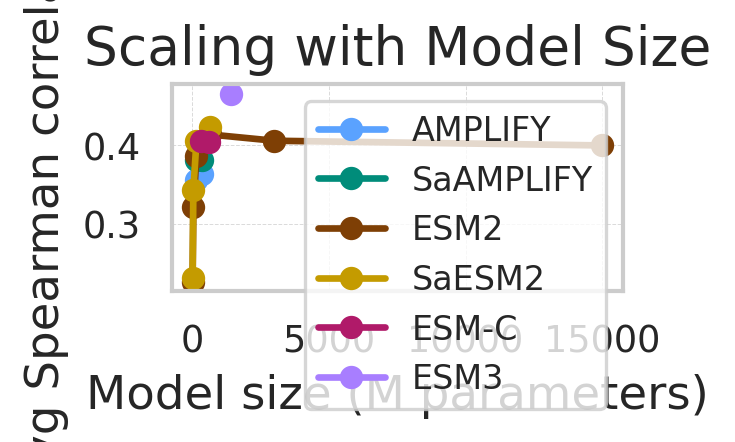

In [20]:
# Plot the average performance vs model size for each model family, using the defined color scheme
# Uses aggregated averages from summary_df

if 'summary_df' in globals() and not summary_df.empty and model_sizes and model_families and 'colors' in globals():
    plt.figure(figsize=(3, 2))
    for family, models in model_families.items():
        fam_models = [m for m in models if m in summary_df['Model_name'].values]
        if not fam_models:
            continue

        family_agg = summary_df[summary_df['Model_name'].isin(fam_models)].copy()
        avg_per_model = (
            family_agg.rename(columns={'Average_Spearman': 'spearman', 'Model_name': 'model'})
            .assign(size=lambda d: d['model'].map(model_sizes))
            .dropna(subset=['size'])
            .sort_values('size')
        )
        if avg_per_model.empty:
            continue

        # Line color: use the largest model in the family to represent family color
        line_color_model = avg_per_model.iloc[-1]['model']
        line_color = colors.get(line_color_model, None)

        plt.plot(
            avg_per_model['size'],
            avg_per_model['spearman'],
            marker='o',
            linewidth=2,
            markersize=6,
            color=line_color,
            label=family
        )

    plt.xlabel('Model size (M parameters)', fontsize=14)
    plt.ylabel('Avg Spearman correlation', fontsize=14)
    plt.title('Scaling with Model Size', fontsize=16)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, which="major", ls="--", linewidth=0.3, alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Data not available for scaling plot.")

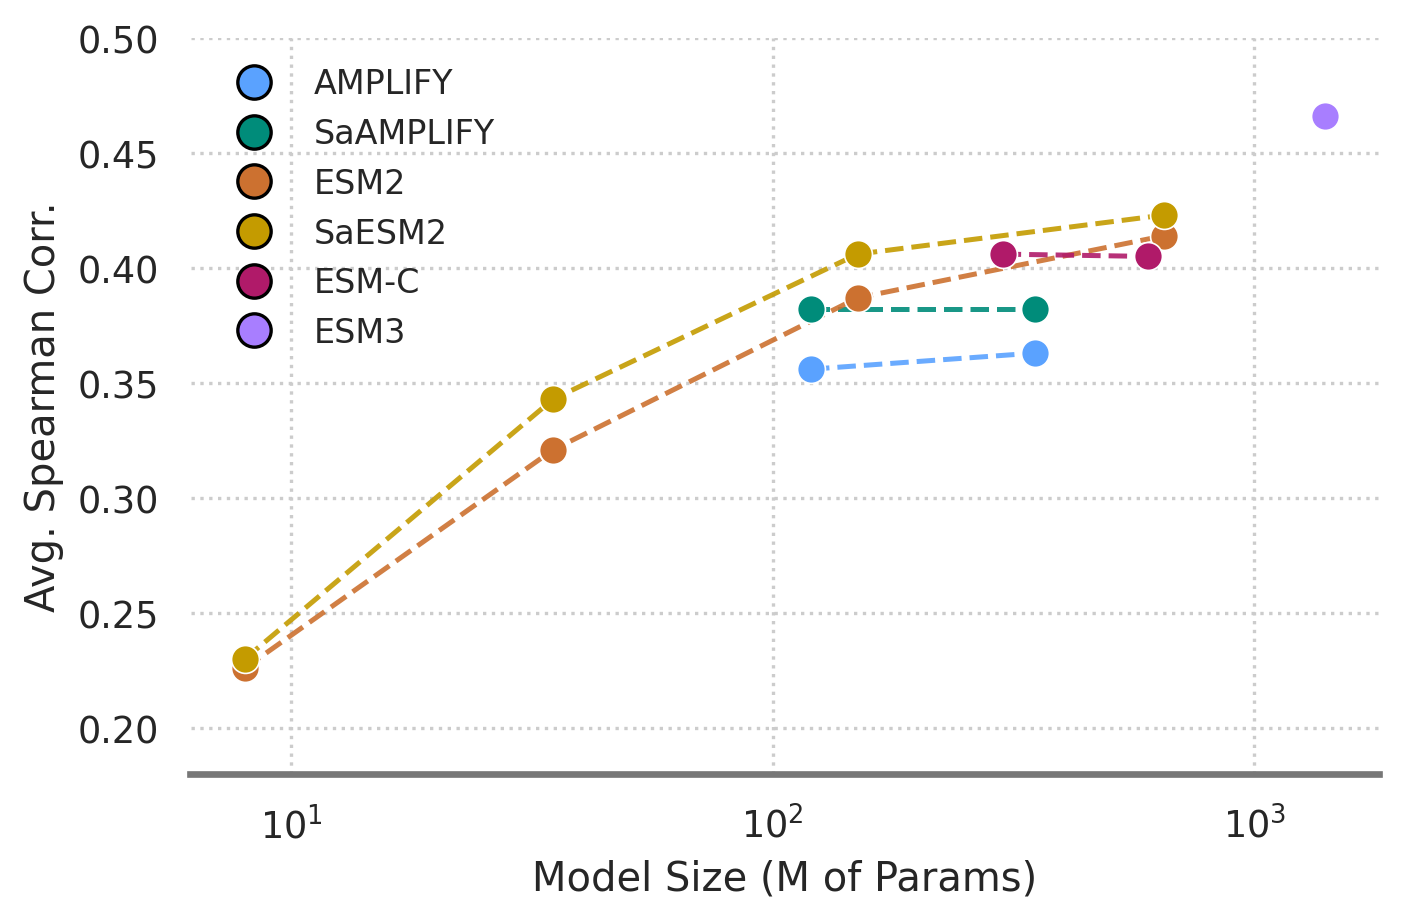

In [21]:
# Plot the average performance vs model size with styling
if 'summary_df' in globals() and not summary_df.empty and model_sizes and model_families and 'colors' in globals():
    from matplotlib.lines import Line2D
    
    plt.figure(figsize=(6, 4))
    for family, models in model_families.items():
        fam_models = [m for m in models if m in summary_df['Model_name'].values]
        # Exclude largest ESM2 models
        if family == "ESM2":
            fam_models = [m for m in fam_models if model_sizes.get(m, 0) <= 650]
        if not fam_models:
            continue

        family_agg = summary_df[summary_df['Model_name'].isin(fam_models)].copy()
        avg_per_model = (
            family_agg.rename(columns={'Average_Spearman': 'spearman', 'Model_name': 'model'})
            .assign(size=lambda d: d['model'].map(model_sizes))
            .dropna(subset=['size'])
            .sort_values('size')
        )
        if avg_per_model.empty:
            continue

        # Line color: use the largest model in the family to represent family color
        line_color_model = avg_per_model.iloc[-1]['model']
        line_color = colors.get(line_color_model, None)

        plt.plot(
            avg_per_model['size'],
            avg_per_model['spearman'],
            linestyle='--',
            color=line_color,
            label=family,
            markersize=0,
            linewidth=1.5,
            alpha=0.9,
        )

        # Point colors: per-model color from the color scheme
        plt.scatter(
            avg_per_model['size'],
            avg_per_model['spearman'],
            s=70,
            color=line_color,
            edgecolor='white',
            linewidth=0.5,
            zorder=3,
        )
    
    ax = plt.gca()
    plt.xscale('log')
    plt.xlabel('Model Size (M of Params)')
    plt.ylabel('Avg. Spearman Corr.')
    plt.ylim(0.18, 0.5)
    plt.axhline(0.0, color='k', lw=1, ls='--', alpha=0.5)
    
    # Apply styling
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["bottom"].set_color("#777777")
    ax.set_axisbelow(True)
    ax.grid(True, which="major", ls=":", linewidth=1)
    
    # Show legend
    handles = []
    for family, models in model_families.items():
        fam_models = [m for m in models if m in summary_df['Model_name'].values]
        if family == "ESM2":
            fam_models = [m for m in fam_models if model_sizes.get(m, 0) <= 650]
        if not fam_models:
            continue
        largest_model = max(fam_models, key=lambda m: model_sizes[m])
        color = colors.get(largest_model, "#333333")
        handles.append(Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markersize=10, label=family))
    plt.legend(handles=handles, fontsize=10, frameon=False)

    plt.tight_layout()
    plt.savefig("scaling_proteingym.png", bbox_inches="tight", dpi=300)
    plt.savefig("scaling_proteingym.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Data not available for scaling plot.")

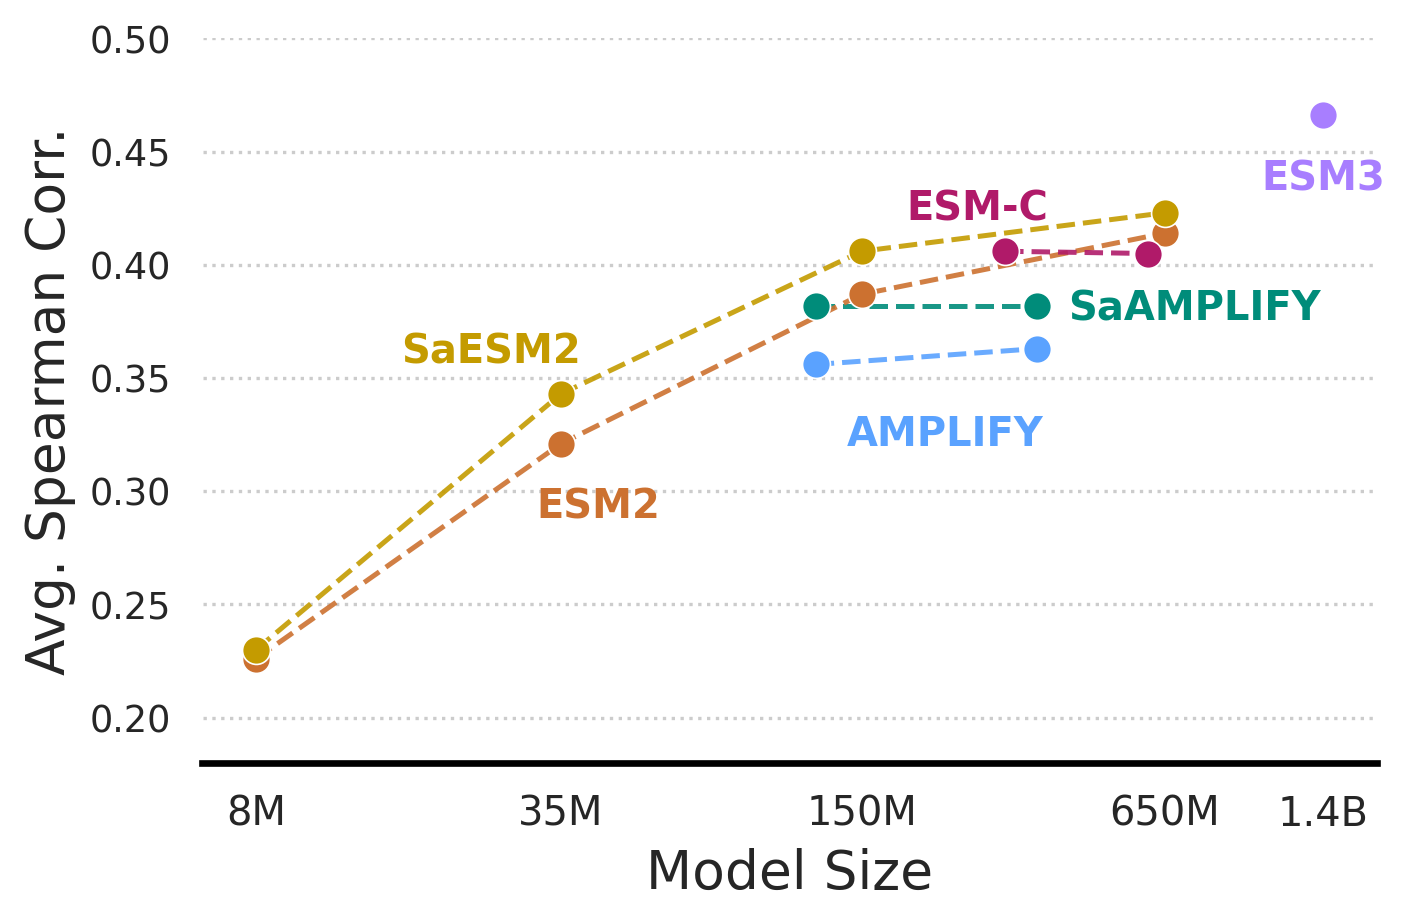

In [22]:
# Styled scaling plot with custom annotations
if 'summary_df' in globals() and not summary_df.empty and model_sizes and model_families and 'colors' in globals():
    plt.figure(figsize=(6, 4))
    family_lines = {}
    for family, models in model_families.items():
        fam_models = [m for m in models if m in summary_df['Model_name'].values]
        if family == "ESM2":
            fam_models = [m for m in fam_models if model_sizes.get(m, 0) <= 650]
        if not fam_models:
            continue

        family_agg = summary_df[summary_df['Model_name'].isin(fam_models)].copy()
        avg_per_model = (
            family_agg.rename(columns={'Average_Spearman': 'spearman', 'Model_name': 'model'})
            .assign(size=lambda d: d['model'].map(model_sizes))
            .dropna(subset=['size'])
            .sort_values('size')
        )
        if avg_per_model.empty:
            continue

        line_color_model = avg_per_model.iloc[-1]['model']
        line_color = colors.get(line_color_model, None)

        plt.plot(
            avg_per_model['size'],
            avg_per_model['spearman'],
            linestyle='--',
            color=line_color,
            label=family,
            markersize=0,
            linewidth=1.5,
            alpha=0.9,
        )
        plt.scatter(
            avg_per_model['size'],
            avg_per_model['spearman'],
            s=70,
            color=line_color,
            edgecolor='white',
            linewidth=0.5,
            zorder=3,
        )
        family_lines[family] = (avg_per_model, line_color)

    ax = plt.gca()
    plt.xscale('log')
    plt.xlabel('Model Size', fontdict={'fontsize': 16})
    plt.ylabel('Avg. Spearman Corr.', fontdict={'fontsize': 16})
    plt.ylim(0.18, 0.5)
    plt.axhline(0.0, color='k', lw=1, ls='--', alpha=0.5)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["bottom"].set_color("#000000")
    ax.set_axisbelow(True)
    ax.grid(True, which="major", ls=":", linewidth=1, axis='y')
    ax.grid(False, axis='x')
    
    # Increase font size of ticks
    xticks = [8, 35, 150, 650, 1400]
    ax.set_xticks(xticks)
    xticks_labels = [f"{int(x)}M" if x < 1e3 else f"{(x/1e3):.1f}B" for x in xticks]
    ax.set_xticklabels(xticks_labels, fontsize=12)
    ax.set_axisbelow(True)
    plt.tight_layout()

    custom_labels = True
    if custom_labels:
        # Custom family label placement
        if "ESM3" in family_lines:
            df, color = family_lines["ESM3"]
            x = df['size'].iloc[0]
            y = df['spearman'].iloc[0]
            ax.annotate("ESM3", (x, y+0.01), xytext=(0, -20), textcoords='offset points',
                        ha='center', va='top', color=color, fontsize=12, fontweight='bold')

        if "ESM-C" in family_lines:
            df, color = family_lines["ESM-C"]
            x = df['size'].iloc[0]
            y = df['spearman'].iloc[0]
            ax.annotate("ESM-C", (x+300, y-0.02), xytext=(-30, 20), textcoords='offset points',
                        ha='right', va='bottom', color=color, fontsize=12, fontweight='bold')

        if "ESM2" in family_lines:
            df, color = family_lines["ESM2"]
            if len(df) > 1:
                x = df['size'].iloc[1]
                y = df['spearman'].iloc[1]
                ax.annotate("ESM2", (x+7, y+0.01), xytext=(0, -20), textcoords='offset points',
                            ha='center', va='top', color=color, fontsize=12, fontweight='bold')

        if "SaESM2" in family_lines:
            df, color = family_lines["SaESM2"]
            if len(df) > 1:
                x = df['size'].iloc[1]
                y = df['spearman'].iloc[1]
                ax.annotate("SaESM2", (x-10, y-0.02), xytext=(0, 20), textcoords='offset points',
                            ha='center', va='bottom', color=color, fontsize=12, fontweight='bold')

        if "AMPLIFY" in family_lines:
            df, color = family_lines["AMPLIFY"]
            x = df['size'].iloc[-1]
            y = df['spearman'].iloc[-1]
            ax.annotate("AMPLIFY", (x-125, y), xytext=(0, -20), textcoords='offset points',
                        ha='center', va='top', color=color, fontsize=12, fontweight='bold')

        if "SaAMPLIFY" in family_lines:
            df, color = family_lines["SaAMPLIFY"]
            x = df['size'].iloc[-1]
            y = df['spearman'].iloc[-1]
            ax.annotate("SaAMPLIFY", (x+400, y-0.04), xytext=(0, 20), textcoords='offset points',
                        ha='center', va='bottom', color=color, fontsize=12, fontweight='bold')

    plt.savefig("scaling_proteingym_annotated.png", bbox_inches="tight", dpi=300)
    plt.savefig("scaling_proteingym_annotated.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Data not available for scaling plot.")

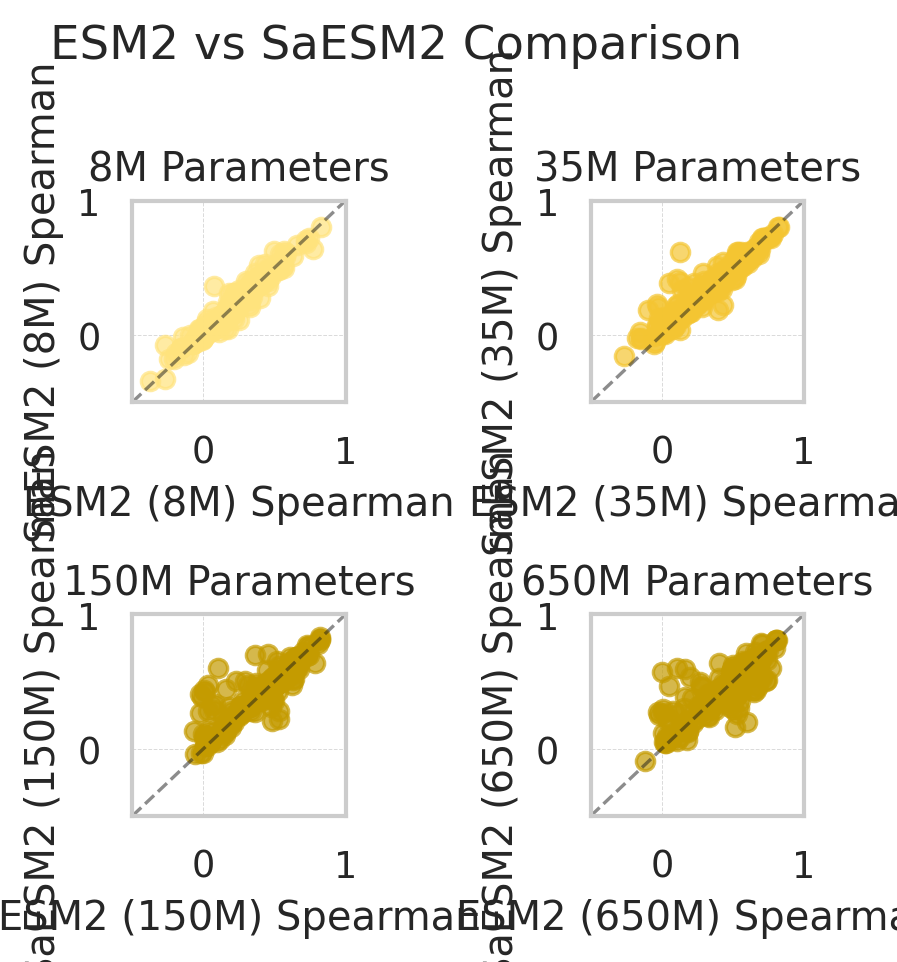

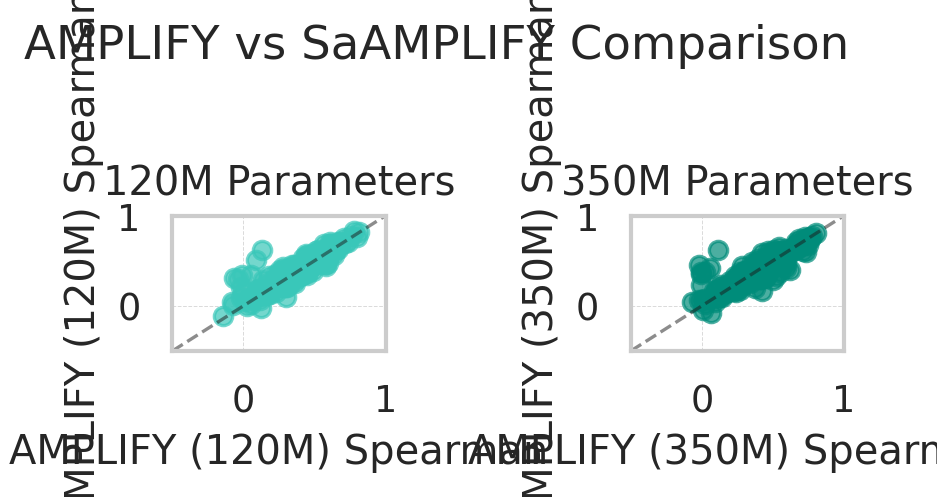

In [23]:
# ESM2 vs SaESM2: 2x2 plot for sizes 8M, 35M, 150M, 650M
if 'long_df' in globals() and not long_df.empty and model_sizes and model_families:
    sa_family = 'SaESM2'
    regular_family = 'ESM2'
    sa_models = model_families.get(sa_family, [])
    regular_models = model_families.get(regular_family, [])
    
    # Define common sizes for ESM2
    esm2_sizes = [8, 35, 150, 650]

    fig, axes = plt.subplots(2, 2, figsize=(4, 4))
    axes = axes.flatten()
    
    for idx, size in enumerate(esm2_sizes):
        sa_model = next((m for m in sa_models if model_sizes.get(m) == size), None)
        reg_model = next((m for m in regular_models if model_sizes.get(m) == size), None)
        
        if sa_model and reg_model:
            sa_data = long_df[long_df['model'] == sa_model].set_index('assay')
            reg_data = long_df[long_df['model'] == reg_model].set_index('assay')
            merged = sa_data.join(reg_data, lsuffix='_sa', rsuffix='_reg', how='inner')
            
            axes[idx].scatter(
                merged['spearman_reg'],
                merged['spearman_sa'],
                s=30,
                alpha=0.7,
                color=colors.get(sa_model, '#333333')
            )
            axes[idx].plot([-0.5, 1], [-0.5, 1], color='k', lw=1, ls='--', alpha=0.5)
            axes[idx].set_xlim(-0.5, 1)
            axes[idx].set_ylim(-0.5, 1)
            axes[idx].set_xlabel(f'{regular_family} ({size}M) Spearman')
            axes[idx].set_ylabel(f'{sa_family} ({size}M) Spearman')
            axes[idx].set_title(f'{size}M Parameters')
            axes[idx].grid(True, which="major", ls="--", linewidth=0.3, alpha=0.7)
    
    plt.suptitle(f'{regular_family} vs {sa_family} Comparison', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# AMPLIFY vs SaAMPLIFY: 1x2 plot for sizes 120M, 350M
if 'long_df' in globals() and not long_df.empty and model_sizes and model_families:
    sa_family = 'SaAMPLIFY'
    regular_family = 'AMPLIFY'
    sa_models = model_families.get(sa_family, [])
    regular_models = model_families.get(regular_family, [])
    
    # Define common sizes for AMPLIFY
    amplify_sizes = [120, 350]
    
    fig, axes = plt.subplots(1, 2, figsize=(4, 2))
    
    for idx, size in enumerate(amplify_sizes):
        sa_model = next((m for m in sa_models if model_sizes.get(m) == size), None)
        reg_model = next((m for m in regular_models if model_sizes.get(m) == size), None)
        
        if sa_model and reg_model:
            sa_data = long_df[long_df['model'] == sa_model].set_index('assay')
            reg_data = long_df[long_df['model'] == reg_model].set_index('assay')
            merged = sa_data.join(reg_data, lsuffix='_sa', rsuffix='_reg', how='inner')
            
            axes[idx].scatter(
                merged['spearman_reg'],
                merged['spearman_sa'],
                s=30,
                alpha=0.7,
                color=colors.get(sa_model, '#333333')
            )
            axes[idx].plot([-0.5, 1], [-0.5, 1], color='k', lw=1, ls='--', alpha=0.5)
            axes[idx].set_xlim(-0.5, 1)
            axes[idx].set_ylim(-0.5, 1)
            axes[idx].set_xlabel(f'{regular_family} ({size}M) Spearman')
            axes[idx].set_ylabel(f'{sa_family} ({size}M) Spearman')
            axes[idx].set_title(f'{size}M Parameters')
            axes[idx].grid(True, which="major", ls="--", linewidth=0.3, alpha=0.7)
    
    plt.suptitle(f'{regular_family} vs {sa_family} Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

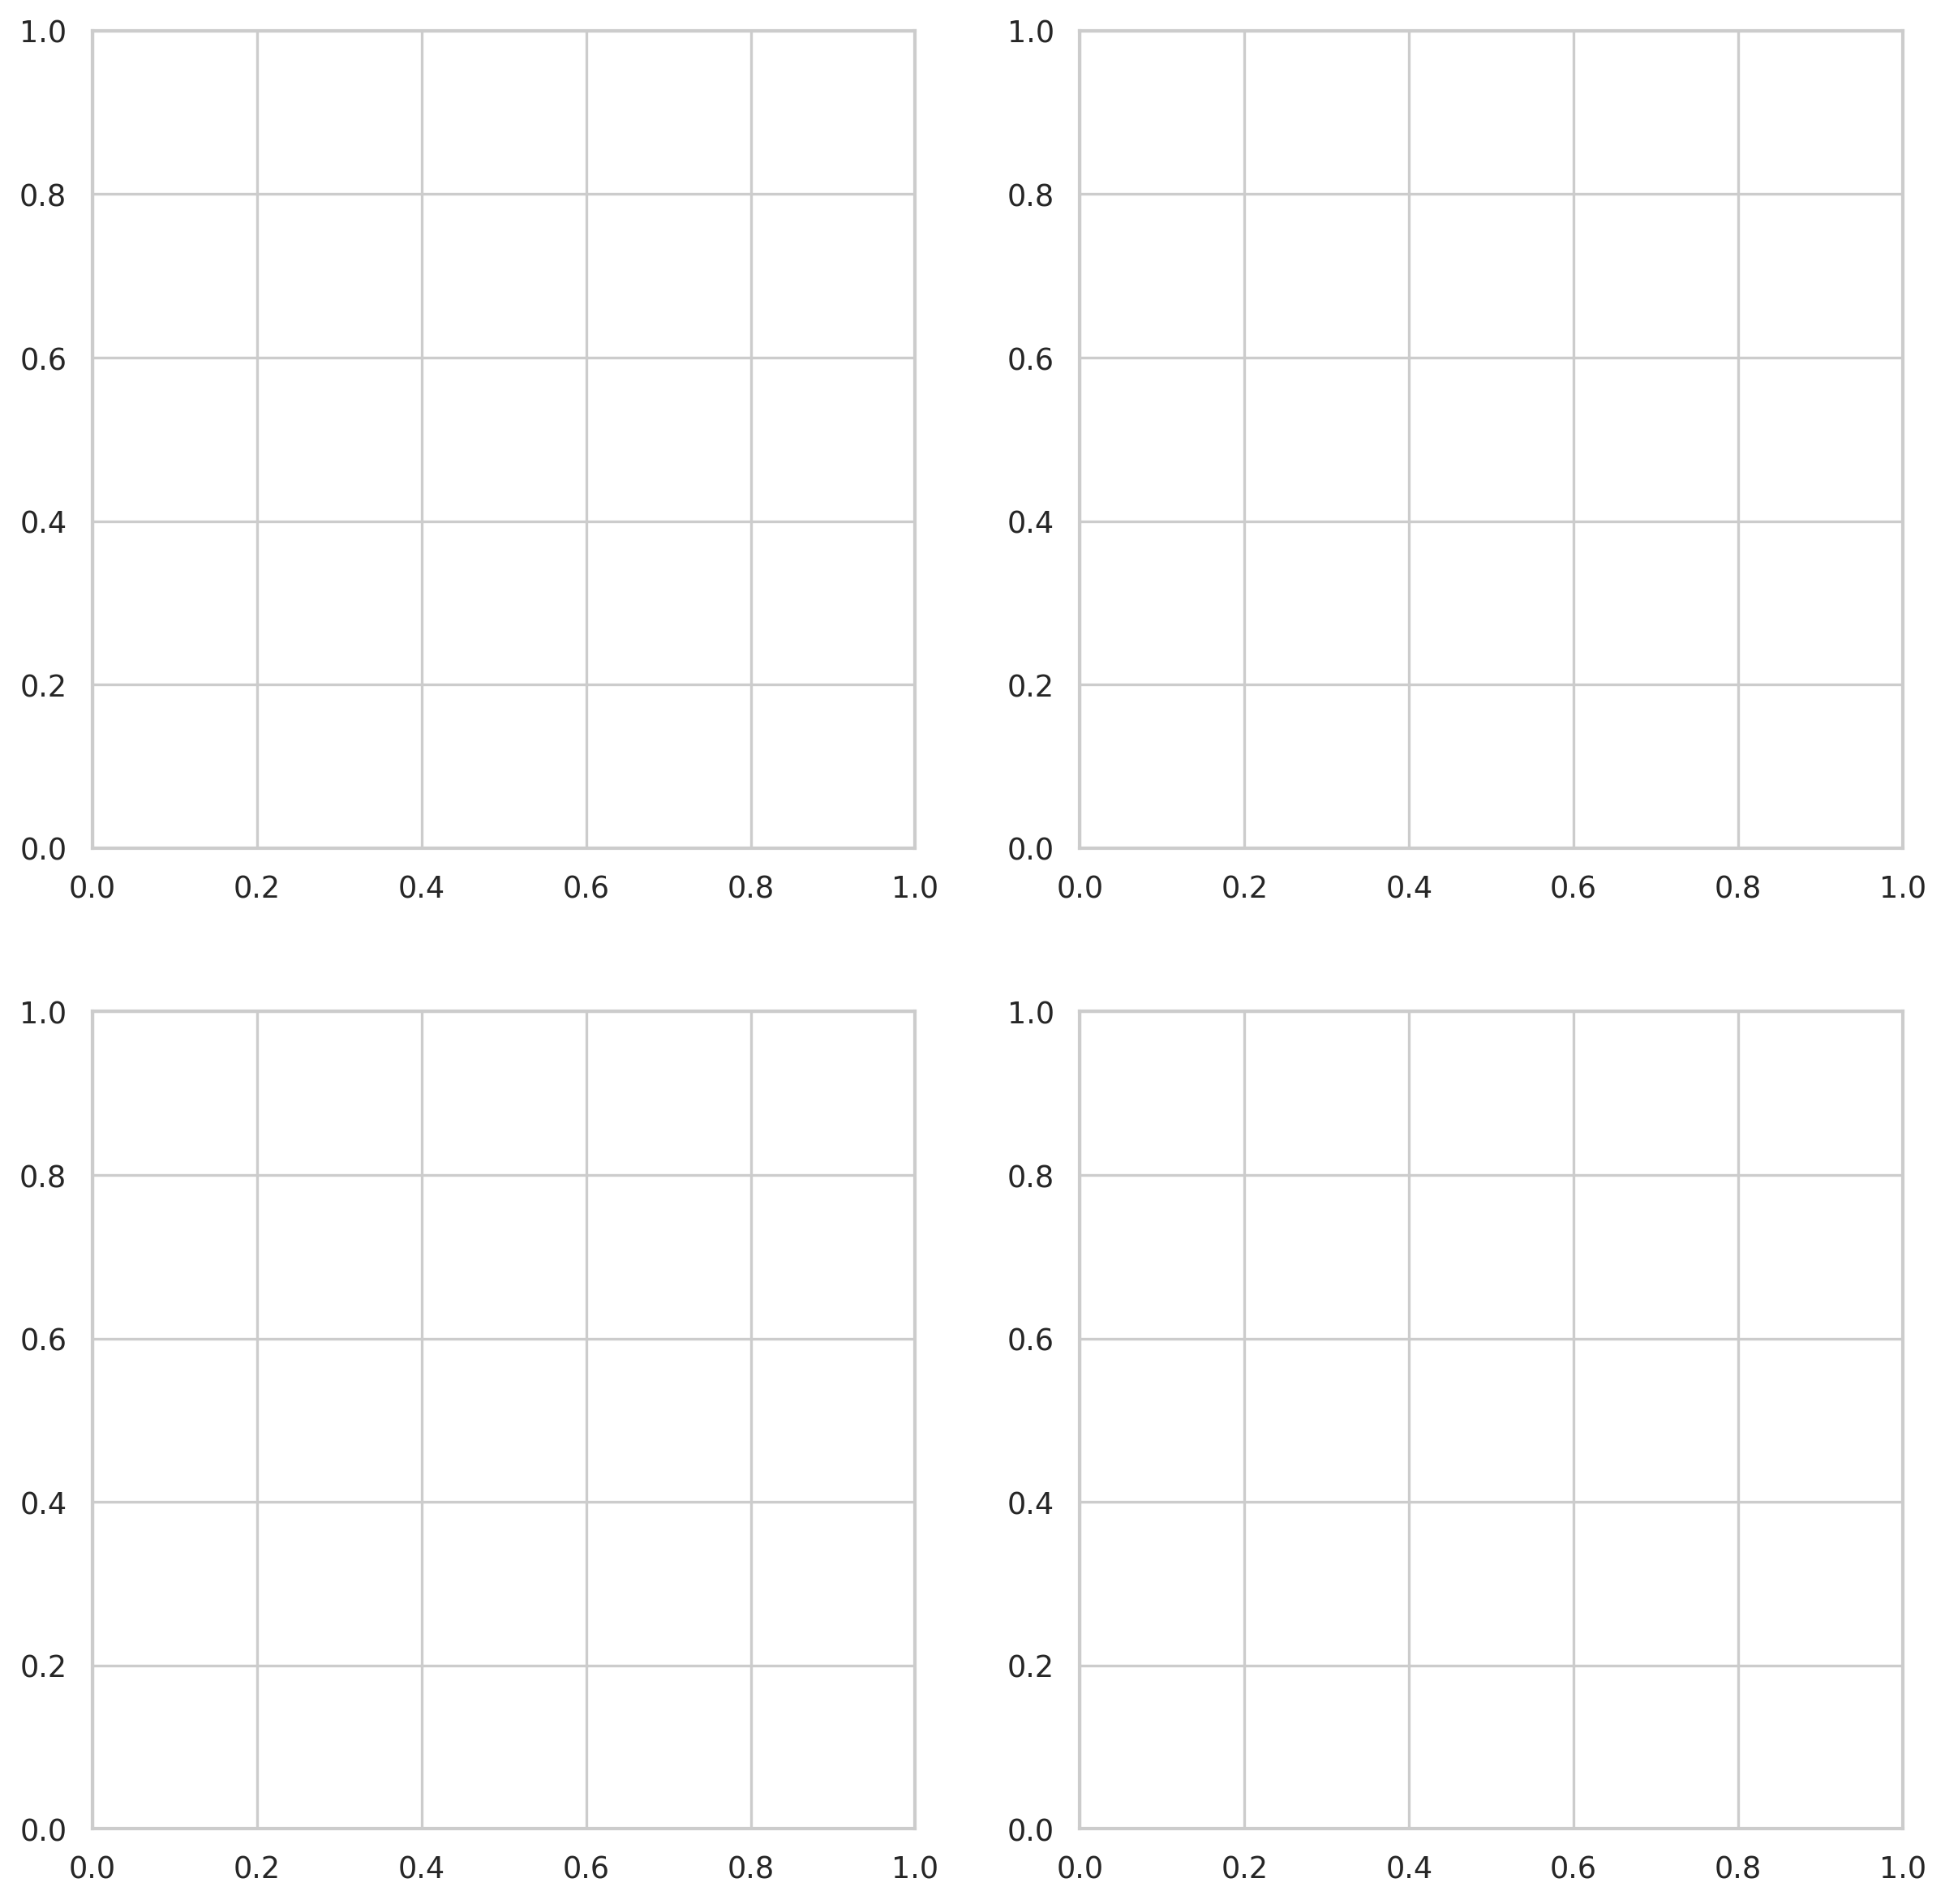

In [24]:
# ESM2 vs SaESM2: 2x2 plot for sizes 8M, 35M, 150M, 650M
if 'long_df' in globals() and not long_df.empty and model_sizes and model_families:
    
    sa_family = 'SaESM2'
    regular_family = 'ESM2'
    sa_models = model_families.get(sa_family, [])
    regular_models = model_families.get(regular_family, [])
    
    # Define common sizes for ESM2
    esm2_sizes = [8, 35, 150, 650]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx, size in enumerate(esm2_sizes):
        sa_model = next((m for m in sa_models if model_sizes.get(m) == size), None)
        reg_model = next((m for m in regular_models if model_sizes.get(m) == size), None)
        
        ax = axes[idx] # Get current subplot axis
        
        if sa_model and reg_model:
            sa_data = long_df[long_df['model'] == sa_model].set_index('assay')
            reg_data = long_df[long_df['model'] == reg_model].set_index('assay')
            merged = sa_data.join(reg_data, lsuffix='_sa', rsuffix='_reg', how='inner')
            # Color below the line --> smallest model (of the whole family)
            # Colors above the line --> largest model (of the whole family)
            merged['color'] = merged['spearman_sa'] >= merged['spearman_reg']
            
            ax.scatter(
                merged['spearman_reg'],
                merged['spearman_sa'],
                s=30,
                alpha=0.7,
                color=merged['color'].map({True: colors.get('SaESM2_150M'), False: colors.get('ESM2 (150M)', '#333333')})
            )
            ax.plot([-0.5, 1], [-0.5, 1], color='k', lw=1, ls=':', alpha=0.9)
            ax.set_xlim(-0.5, 1)
            ax.set_ylim(-0.5, 1)
            ax.set_xlabel(f'{regular_family} ({size}M) Spearman', fontsize=12)
            ax.set_ylabel(f'{sa_family} ({size}M) Spearman', fontsize=12)
            
            # --- Apply Blog Guidelines ---
            # ax.grid(False, which="major", ls=":")
            ax.grid(False)
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.set_axisbelow(True) # Put grid behind
            ax.spines[["top", "right"]].set_visible(False) # Remove top/right spines
            ax.spines["bottom"].set_linewidth(1.5) # Thicken bottom spine
            ax.spines["bottom"].set_color("#000000") # Color bottom spine
            ax.spines["left"].set_linewidth(1.5) # Thicken left spine
            ax.spines["left"].set_color("#000000") # Color left spine
            ax.set_aspect('equal', adjustable='box') # Set aspect ratio to equal
            # --- End Guidelines ---
    
    # plt.suptitle(f'{regular_family} / {sa_family} Comparison', fontsize=14, y=0.995)

    plt.savefig("esm2_vs_saesm2_proteingym.png", bbox_inches="tight", dpi=300)
    plt.savefig("esm2_vs_saesm2_proteingym.pdf", bbox_inches="tight")

    plt.tight_layout()
    plt.show()

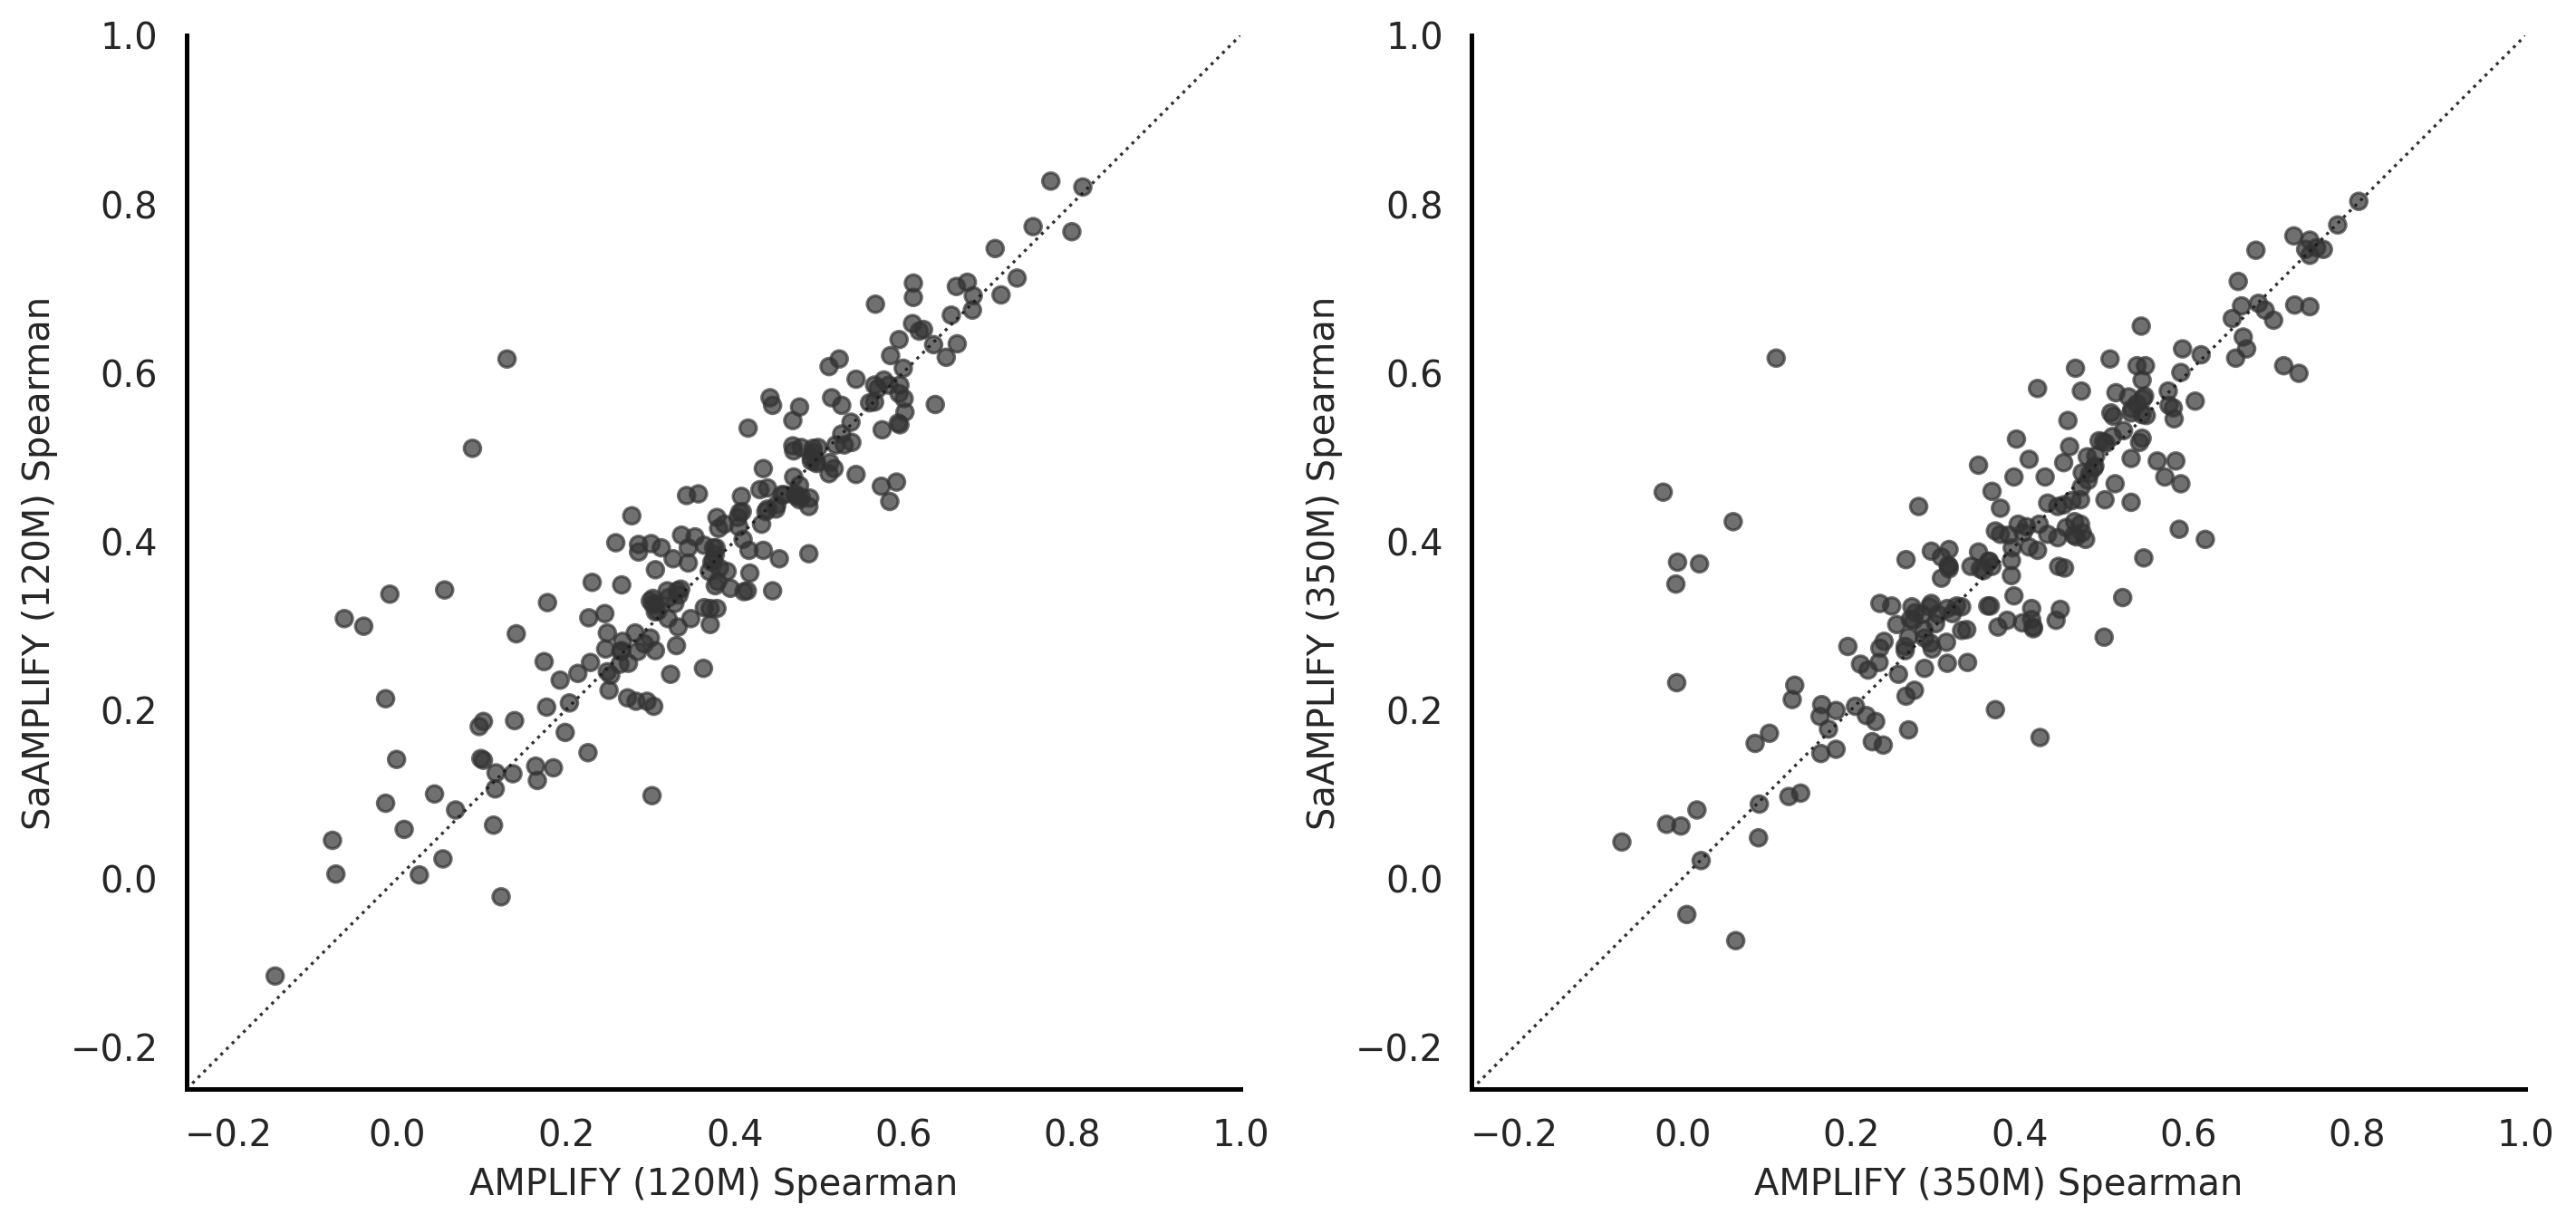

In [ ]:
# AMPLIFY vs SaAMPLIFY: 1x2 plot for sizes 120M, 350M
if 'long_df' in globals() and not long_df.empty and model_sizes and model_families:
    # Set display quality
    
    sa_family = 'SaAMPLIFY'
    regular_family = 'AMPLIFY'
    sa_models = model_families.get(sa_family, [])
    regular_models = model_families.get(regular_family, [])
    
    # Define common sizes for AMPLIFY
    amplify_sizes = [120, 350]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    for idx, size in enumerate(amplify_sizes):
        sa_model = next((m for m in sa_models if model_sizes.get(m) == size), None)
        reg_model = next((m for m in regular_models if model_sizes.get(m) == size), None)
        
        ax = axes[idx] # Get current subplot axis

        if sa_model and reg_model:
            sa_data = long_df[long_df['model'] == sa_model].set_index('assay')
            reg_data = long_df[long_df['model'] == reg_model].set_index('assay')
            merged = sa_data.join(reg_data, lsuffix='_sa', rsuffix='_reg', how='inner')

            merged['color'] = merged['spearman_sa'] >= merged['spearman_reg']
            
            ax.scatter(
                merged['spearman_reg'],
                merged['spearman_sa'],
                s=30,
                alpha=0.7,
                color=merged['color'].map({True: colors.get('SaAMPLIFY_120M', '#333333'), False: colors.get('AMPLIFY_120M', '#333333')})
            )
            ax.plot([-0.25, 1], [-0.25, 1], color='k', lw=1, ls=':', alpha=0.9)
            ax.set_xlim(-0.25, 1)
            ax.set_ylim(-0.25, 1)
            ax.set_xlabel(f'{regular_family} ({size}M) Spearman', fontsize=12)
            ax.set_ylabel(f'{sa_family} ({size}M) Spearman', fontsize=12)
            
            # --- Apply Blog Guidelines ---
            # ax.grid(False, which="major", ls=":")
            ax.grid(False)
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.set_axisbelow(True) # Put grid behind
            ax.spines[["top", "right"]].set_visible(False) # Remove top/right spines
            ax.spines["bottom"].set_linewidth(1.5) # Thicken bottom spine
            ax.spines["bottom"].set_color("#000000") # Color bottom spine
            ax.spines["left"].set_linewidth(1.5) # Thicken left spine
            ax.spines["left"].set_color("#000000") # Color left spine
            ax.set_aspect('equal', adjustable='box') # Set aspect ratio to equal
            # --- End Guidelines ---
    
    # plt.suptitle(f'{regular_family} / {sa_family} Comparison', fontsize=14, y=1.02)

    plt.savefig("amplify_saamplify_comparison_proteingym.png", bbox_inches="tight", dpi=300)
    plt.savefig("amplify_saamplify_comparison_proteingym.pdf", bbox_inches="tight")

    plt.tight_layout()
    plt.show()

In [ ]:
# For each pair of regular vs structure aligned models, please find the top 5 assays 
# where there is the largest difference in positive spearman correlation 
# and the top 5 assays where there is the largest difference in negative spearman correlation

if 'long_df' in globals() and not long_df.empty:
    comparison_pairs = [
        ('ESM2', 'SaESM2'),
        ('AMPLIFY', 'SaAMPLIFY'),
    ]
    
    for regular_family, sa_family in comparison_pairs:
        sa_models = model_families.get(sa_family, [])
        regular_models = model_families.get(regular_family, [])
        
        for size in set(model_sizes.get(m) for m in sa_models).intersection(
            set(model_sizes.get(m) for m in regular_models)
        ):
            sa_model = next((m for m in sa_models if model_sizes.get(m) == size), None)
            reg_model = next((m for m in regular_models if model_sizes.get(m) == size), None)
            
            if sa_model and reg_model:
                sa_data = long_df[long_df['model'] == sa_model].set_index('assay')
                reg_data = long_df[long_df['model'] == reg_model].set_index('assay')
                merged = sa_data.join(reg_data, lsuffix='_sa', rsuffix='_reg', how='inner')
                merged['diff'] = merged['spearman_sa'] - merged['spearman_reg']
                
                top_positive_diff = merged.nlargest(5, 'diff')
                top_negative_diff = merged.nsmallest(5, 'diff')
                
                print(f"\nTop 5 Positive Differences for {regular_family} vs {sa_family} ({size}M):")
                print(top_positive_diff[['spearman_reg', 'spearman_sa', 'diff']])
                
                print(f"\nTop 5 Negative Differences for {regular_family} vs {sa_family} ({size}M):")
                print(top_negative_diff[['spearman_reg', 'spearman_sa', 'diff']])

TypeError: Column 'diff' has dtype object, cannot use method 'nlargest' with this dtype

In [ ]:
# I want a list of df of raw scores, for the following models: ESM2, SaESM2, AMPLIFY_350, SaAMPLIFY_350.
# I want 4 lists, each list containing dataframes for each assay, with columns: 'mutation', 'true_score', 'predicted_score'.

def load_raw_scores_for_models(model_paths: Dict[str, str], target_models: List[str]) -> Dict[str, List[pd.DataFrame]]:
    model_dfs: Dict[str, List[pd.DataFrame]] = {model: [] for model in target_models}
    
    for model_name in target_models:
        path = model_paths.get(model_name)
        if path is None or path == "precomputed":
            print(f"Skipping model '{model_name}': no path provided or precomputed.")
            continue
        
        root = Path(str(path).strip())
        if not root.exists():
            print(f"Skipping model '{model_name}': path not found -> {root}")
            continue
        
        for csv_path in iter_assay_csvs(root):
            df = pd.read_csv(csv_path)
            if df.empty:
                print(f"Skipping empty CSV for model '{model_name}' at '{csv_path}'")
                continue

            truth_col = _find_truth_col(df)
            if truth_col is None:
                print(f"Skipping CSV for model '{model_name}' at '{csv_path}': no ground-truth column found.")
                continue
            
            score_cols = _find_model_score_cols(df)
            if not score_cols:
                print(f"Skipping CSV for model '{model_name}' at '{csv_path}': no model score columns found.")
                continue
            
            # Choose the last score column as the predicted score
            predicted_col = score_cols[-1]
            
            # Create a DataFrame with required columns
            result_df = df[[truth_col, predicted_col]].copy()
            result_df.columns = ['true_score', 'predicted_score']
            
            # Add mutation column if available
            result_df['mutant'] = df['mutant']
            model_dfs[model_name].append(result_df)

    return model_dfs

# Example usage:
target_models = ["ESM2 (650M)", "SaESM2_650M", "AMPLIFY_350M", "SaAMPLIFY_350M"]
raw_scores = load_raw_scores_for_models(model_paths, target_models)

Skipping model 'ESM2 (650M)': no path provided or precomputed.


In [ ]:
df = raw_scores['AMPLIFY_350M'][0] # Display the first few rows of the first assay for AMPLIFY_350M

(array([8.217e+03, 6.190e+02, 2.910e+02, 1.520e+02, 8.200e+01, 4.900e+01,
        4.300e+01, 2.700e+01, 2.700e+01, 1.500e+01, 1.100e+01, 7.000e+00,
        6.000e+00, 5.000e+00, 6.000e+00, 1.000e+00, 2.000e+00, 6.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 0.000e+00, 2.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00]),
 array([2.35396602e-03, 2.83578456e-01, 5.64802947e-01, 8.46027437e-01,
        1.12725193e+00, 1.40847642e+00, 1.68970091e+00, 1.97092540e+00,
        2.25214989e+00, 2.53337438e+00, 2.81459887e+00, 3.09582336e+00,
        3.37704785e+00, 3.65827234e+00, 3.93949683e+00, 4.22072132e+00,
        4.50194581e+00, 4.78317030e+00, 5.06439479e+00, 5.34561928e+00,
        5.62684377e+00, 5.90806826e+00, 6.18929275e+00, 6.47051725e+00,
        6.75174174e+00, 7.03296623e+00, 7.31419072e+00, 7.59541521e+00,
        7.87663970e+00, 8.15786419e+00, 8.43908868e+00]),
 <BarContainer object of 30 artists>)

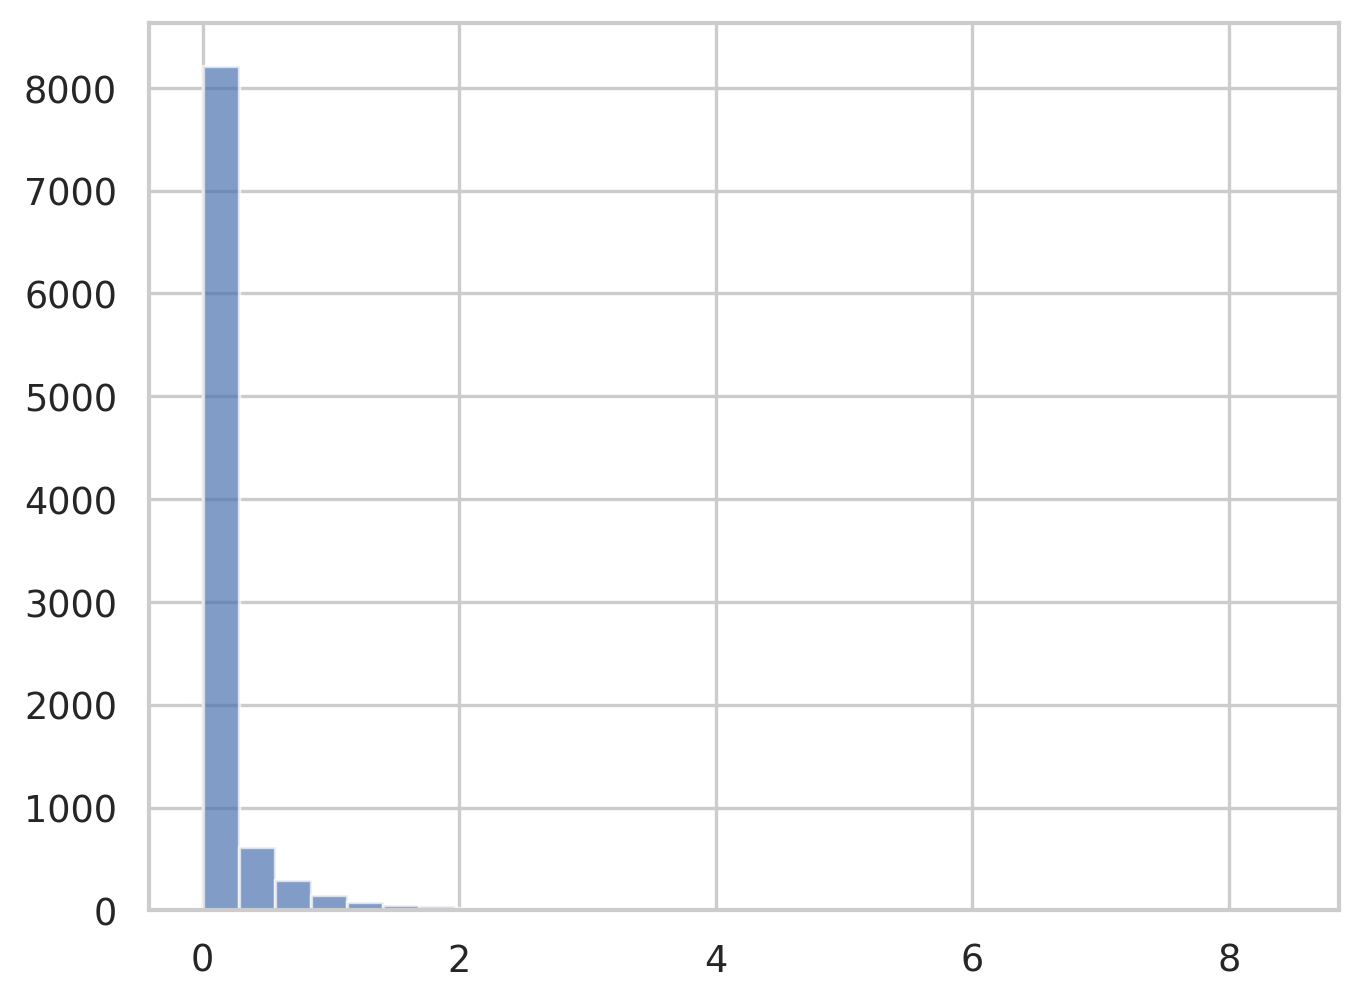

In [ ]:
plt.hist((df['true_score']), bins=30, alpha=0.7)
# plt.hist(df['predicted_score'], bins=30, alpha=0.7)

In [ ]:
if 'raw_scores' in globals() and 'AMPLIFY_350M' in raw_scores:
    amplify_dfs = raw_scores['AMPLIFY_350M']
    for assay_df in amplify_dfs:
        # Compute mutation depth
        assay_df['mutation_depth'] = assay_df['mutant'].apply(lambda x: len(x.split(':')) if pd.notna(x) else 0)
        assay_df['normalized_mutation_depth'] = assay_df['mutation_depth'] / assay_df['mutation_depth'].max()
        
        # Normalize true_score and predicted_score ranks
        assay_df['true_score_rank'] = assay_df['true_score'].rank(method='min', pct=True)
        assay_df['predicted_score_rank'] = assay_df['predicted_score'].rank(method='min', pct=True)
        
        assay_df['true_score_rank'] = (assay_df['true_score_rank'] - assay_df['true_score_rank'].min()) / (assay_df['true_score_rank'].max() - assay_df['true_score_rank'].min())
        assay_df['predicted_score_rank'] = (assay_df['predicted_score_rank'] - assay_df['predicted_score_rank'].min()) / (assay_df['predicted_score_rank'].max() - assay_df['predicted_score_rank'].min())

    combined_df = pd.concat([df for df in amplify_dfs if len(df)], ignore_index=True)
else:
    combined_df = pd.DataFrame()

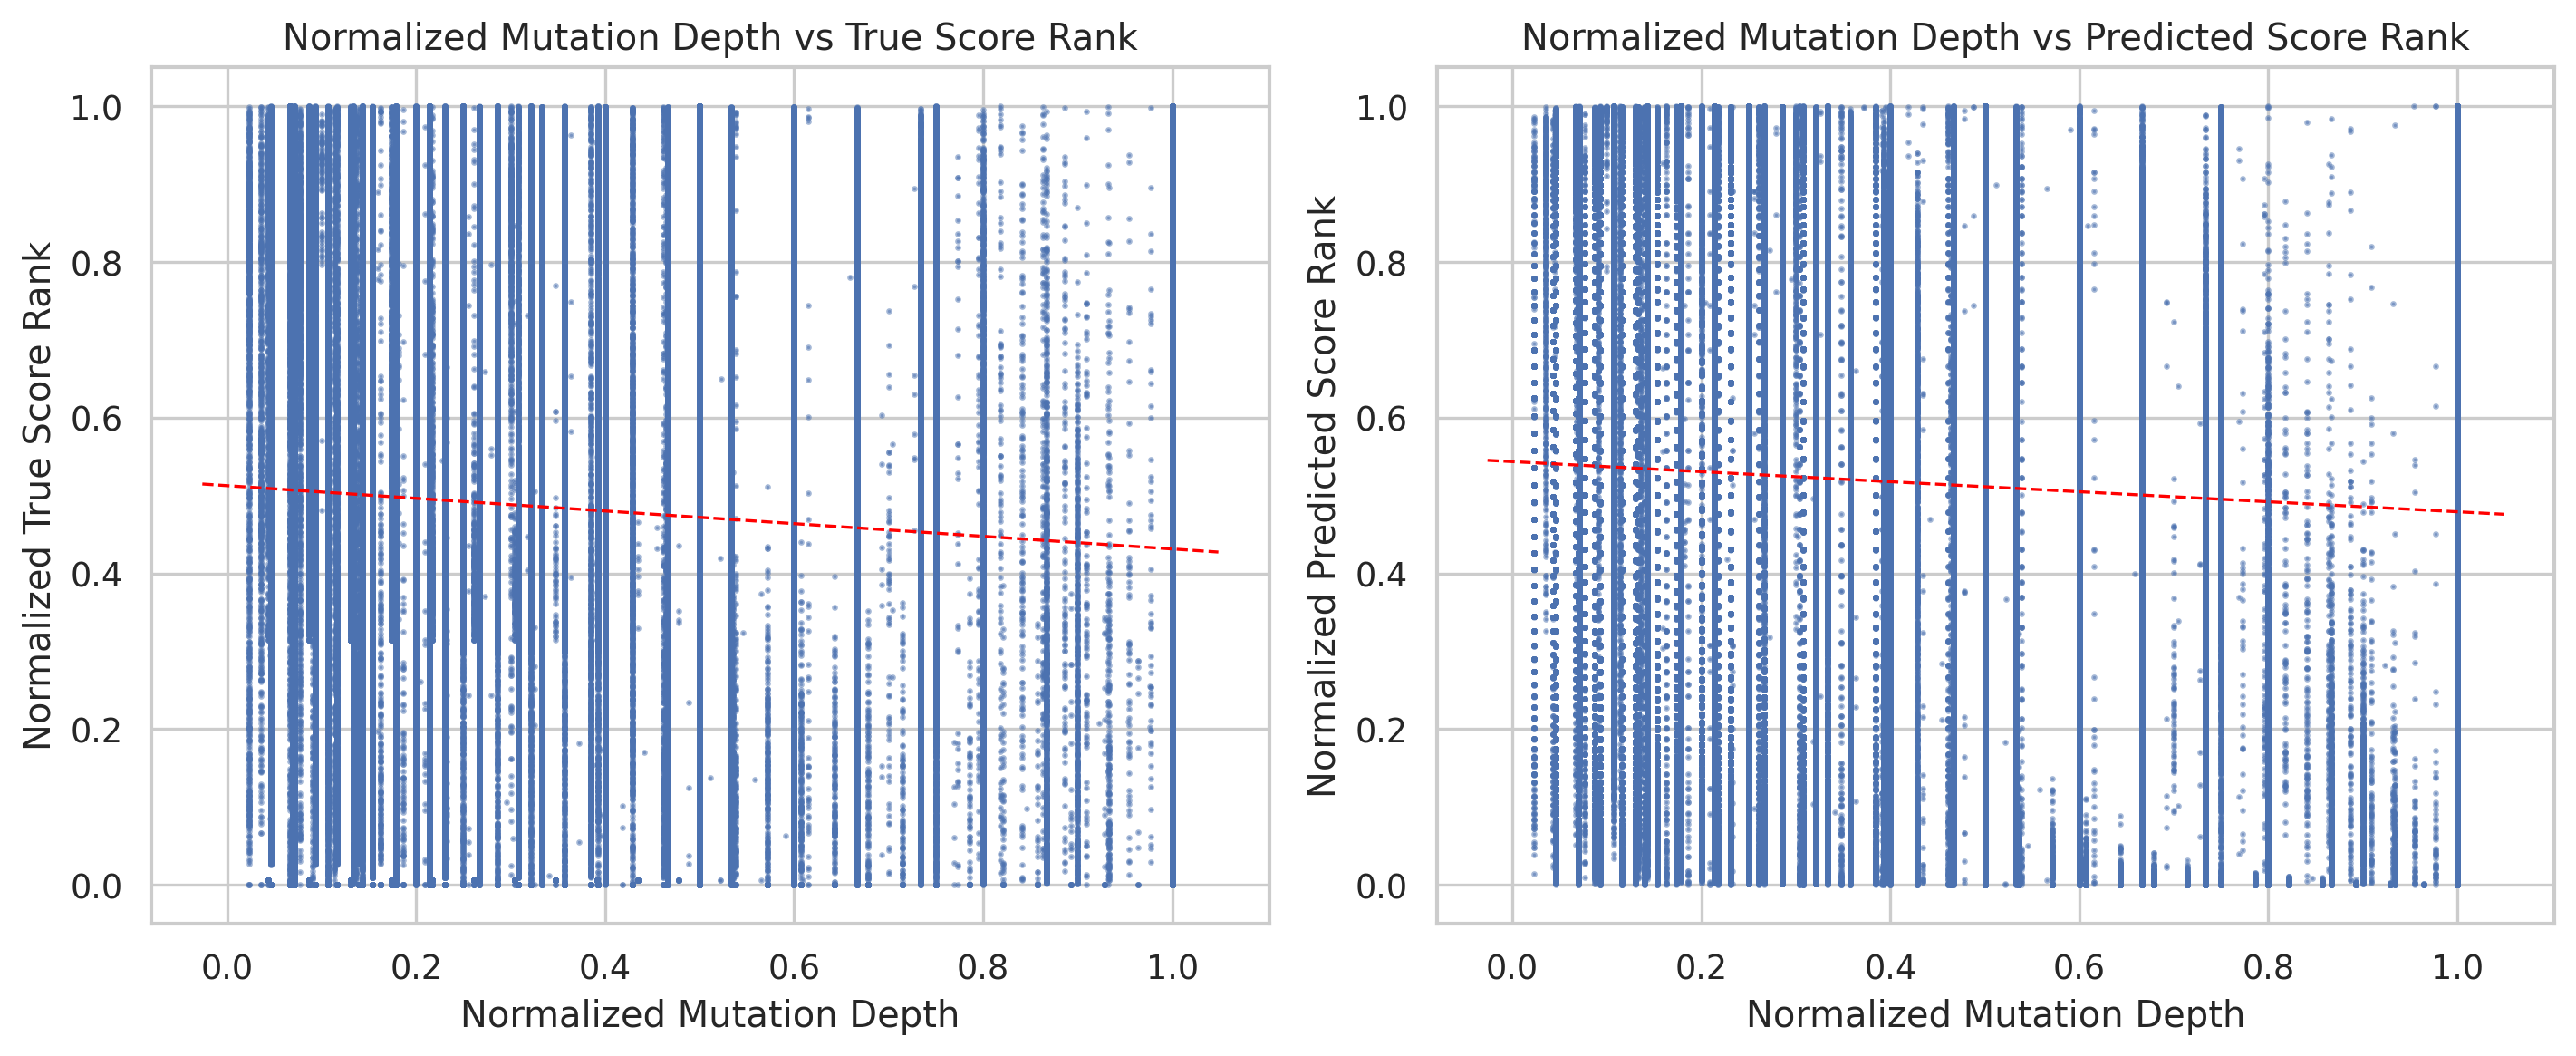

In [ ]:
# I want you to make two scatter plots for AMPLIFY 350M:
# 1) mutation_depth vs true_score_rank , normalized between 0 and 1
# 2) mutation_depth vs predicted_score_rank, normalized between 0 and 1
# Mutation depth can be computed as the number of mutations in the 'mutant' column (assuming it's a string of mutations separated by commas).
# Agregate that for all assays available for AMPLIFY 350M.
if not combined_df.empty:
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].scatter(combined_df['normalized_mutation_depth'], combined_df['true_score_rank'], alpha=0.5, s=1)
    axs[0].set_xlabel('Normalized Mutation Depth')
    axs[0].set_ylabel('Normalized True Score Rank')
    axs[0].set_title('Normalized Mutation Depth vs True Score Rank')
    axs[1].scatter(combined_df['normalized_mutation_depth'], combined_df['predicted_score_rank'], alpha=0.5, s=1)
    axs[1].set_xlabel('Normalized Mutation Depth')
    axs[1].set_ylabel('Normalized Predicted Score Rank')
    axs[1].set_title('Normalized Mutation Depth vs Predicted Score Rank')
    # Add a regression line to each plot
    for ax in axs:
        offsets = ax.collections[0].get_offsets()
        x = offsets[:, 0]
        y = offsets[:, 1]
        mask = ~np.isclose(x, 1.0, atol=1e-12)
        if mask.sum() >= 2:
            z = np.polyfit(x[mask], y[mask], 1)
            p = np.poly1d(z)
            x_line = np.array(ax.get_xlim())
            ax.plot(x_line, p(x_line), color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()
else:
    print("No raw scores available for AMPLIFY_350M to plot.")